# 6CS012 – Artificial Intelligence and Machine Learning
## Part II: Image Classification with Convolutional Neural Networks
### Dataset: Traffic Sign Classification (4 Classes)

**Student Name:** Pabina Shrestha
**WLV ID:** 2408294  
**Date:** April 2026




## Step 0 — Setup: Copy Dataset from Kaggle Input


In [1]:
# ── Kaggle: Copy dataset from input to working directory ──
import shutil, os

SOURCE = '/kaggle/input/datasets/pabinashrestha/traffic-sign/Traffic_Sign/Train'
DEST   = '/kaggle/working/traffic_sign_train_copy'

if os.path.exists(DEST):
    shutil.rmtree(DEST)  

shutil.copytree(SOURCE, DEST)
print(f'Dataset copied to: {DEST}')

for root, dirs, files_list in os.walk(DEST):
    level = root.replace(DEST, '').count(os.sep)
    if level < 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 1:
            print(f'  {indent}({len(files_list)} images)')


Dataset copied to: /kaggle/working/traffic_sign_train_copy
traffic_sign_train_copy/
  Caution/
    (2429 images)
  No Passing/
    (5369 images)
  Instructions/
    (2848 images)
  OverSpeed/
    (5249 images)


## Step 1 — Imports & Environment Check

In [2]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import regularizers

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version :', tf.__version__)
print('GPU available       :', tf.config.list_physical_devices('GPU'))
print('Imports successful  : ✓')


2026-05-09 16:06:01.270261: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778342761.795895      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778342761.915043      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778342763.017652      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778342763.017700      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778342763.017703      57 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Imports successful  : ✓


## Step 2 — Global Configuration

In [3]:
import os

# ── Dataset Paths ──
TRAIN_DIR = '/kaggle/working/traffic_sign_train_copy'   
TEST_DIR  = '/kaggle/input/datasets/pabinashrestha/traffic-sign/Traffic_Sign/Test'
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
# ── Hyperparameters ──
IMG_HEIGHT  = 64
IMG_WIDTH   = 64
BATCH_SIZE  = 32
NUM_CLASSES = len(CLASS_NAMES) 
SEED        = 42

print('Classes detected :', CLASS_NAMES)
print('Train dir exists :', os.path.isdir(TRAIN_DIR))
print('Test  dir exists :', os.path.isdir(TEST_DIR))


Classes detected : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Train dir exists : True
Test  dir exists : True


## Step 3 — Part A: Data Understanding, Analysis, Visualisation & Cleaning

### 3.1 Dataset Description

The **Traffic Sign** dataset is a multi-class, single-image classification dataset collected from
real-world traffic scenarios in Nepal and similar environments. It contains four semantically
distinct categories of road signs:



The `Train/` folder is organised into class sub-folders; `Test/` contains unlabelled images
for inference.


In [4]:
# ── 3.2 Count images per class ──
class_counts = {}
total_train  = 0

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs     = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[cls] = len(imgs)
    total_train      += len(imgs)

print(f'Total training images : {total_train}')
print(f'Number of classes     : {NUM_CLASSES}')
print()
for cls, cnt in class_counts.items():
    print(f'  {cls:<20} {cnt:>5}  ({100 * cnt / total_train:.1f} %)')


Total training images : 15895
Number of classes     : 4

  Caution               2429  (15.3 %)
  Instructions          2848  (17.9 %)
  No Passing            5369  (33.8 %)
  OverSpeed             5249  (33.0 %)


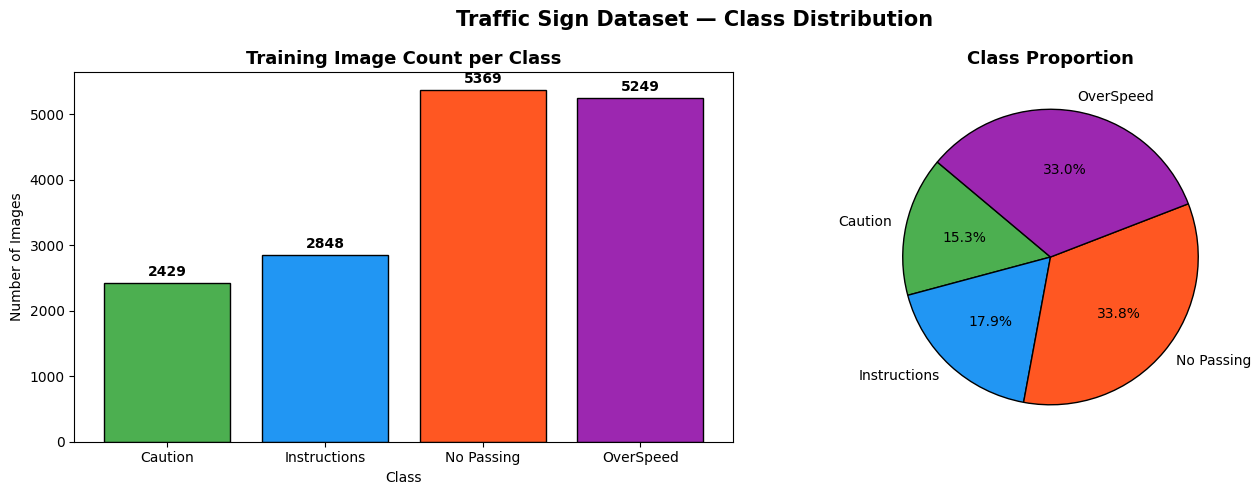


Observation: Check whether the dataset is balanced or imbalanced across the 4 classes.


In [5]:
# ── 3.3 Class distribution bar + pie charts ──
COLORS = ['#4CAF50', '#2196F3', '#FF5722', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(class_counts.keys(), class_counts.values(),
                   color=COLORS, edgecolor='black')
axes[0].set_title('Training Image Count per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for bar, cnt in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(class_counts.values()) * 0.02,
                 str(cnt), ha='center', fontweight='bold')

axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            colors=COLORS, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Traffic Sign Dataset — Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: Check whether the dataset is balanced or imbalanced across the 4 classes.')


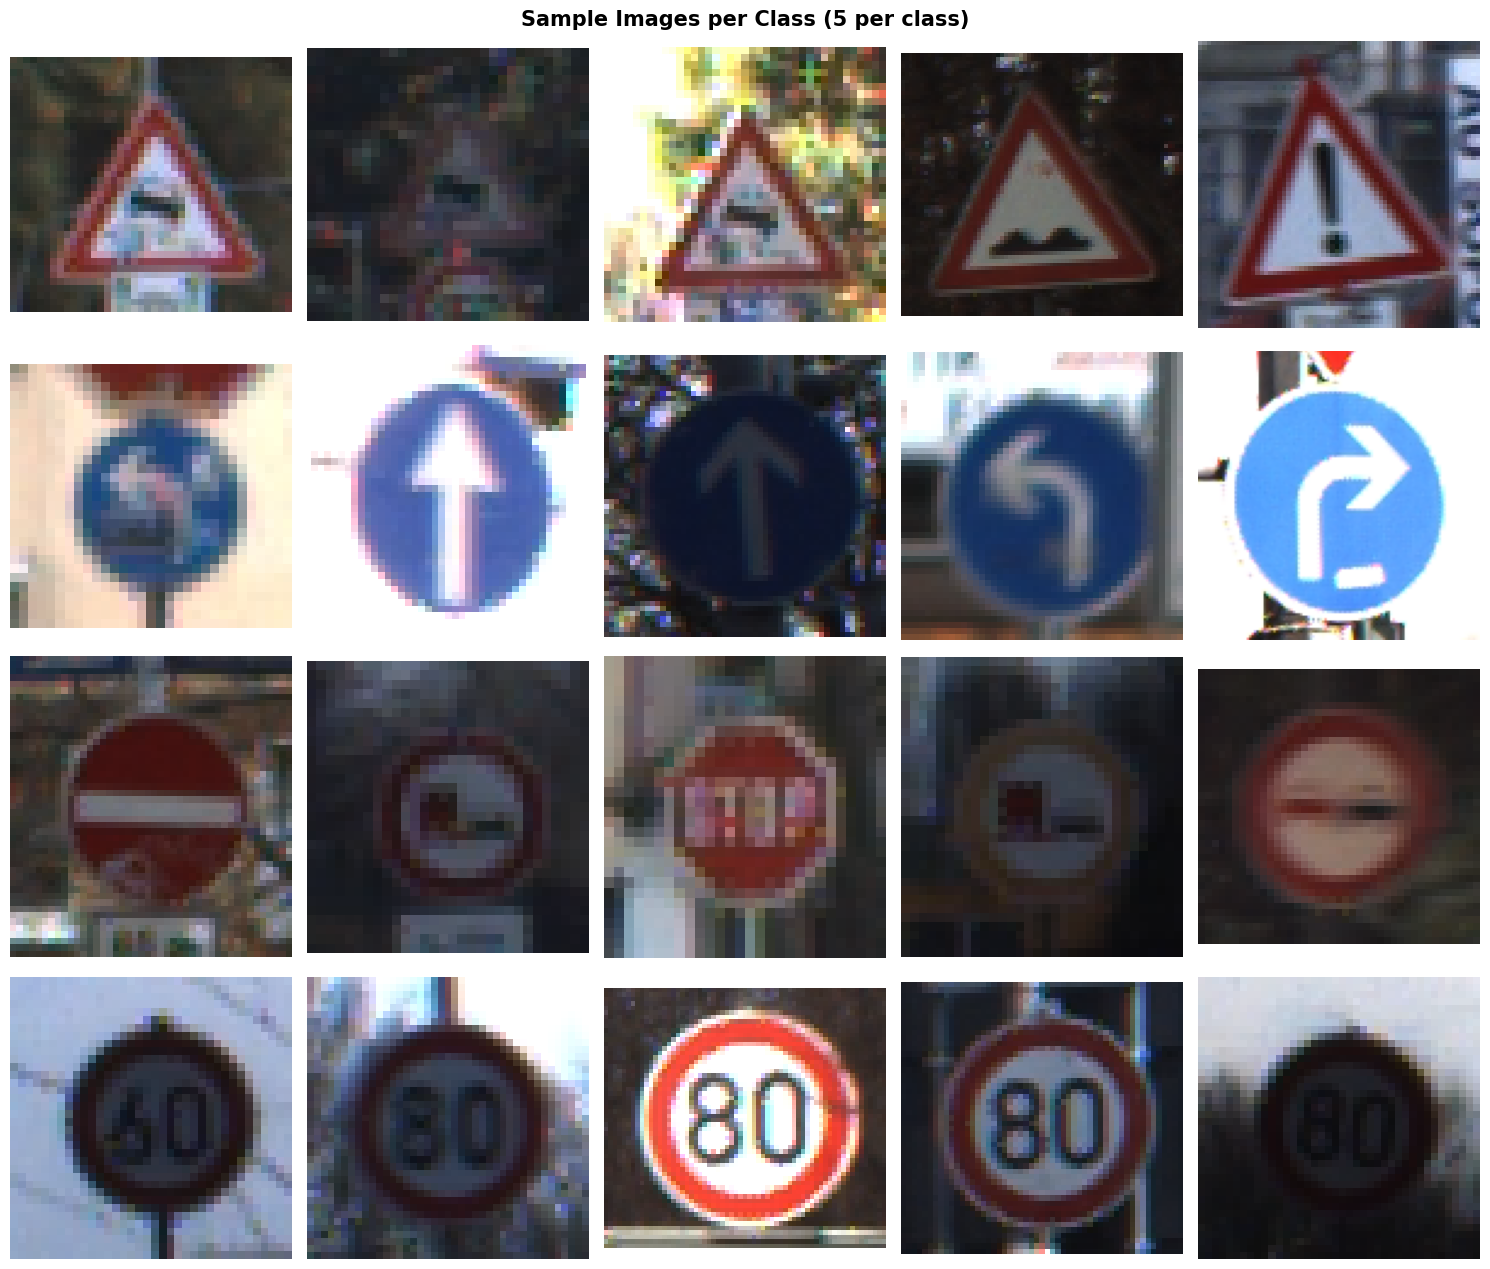

In [6]:
# ── 3.4 Sample images: 5 per class ──
fig, axes = plt.subplots(4, 5, figsize=(15, 13))

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    samples  = np.random.choice(images, min(5, len(images)), replace=False)

    for col, img_name in enumerate(samples):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, fontweight='bold',
                                      rotation=0, labelpad=80, va='center')

plt.suptitle('Sample Images per Class (5 per class)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ── 3.5 Image size distribution ──
widths, heights = [], []

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs     = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:100]
    for f in imgs:
        try:
            with Image.open(os.path.join(cls_path, f)) as im:
                w, h = im.size
                widths.append(w)
                heights.append(h)
        except Exception:
            pass

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}')
print(f'\n➜ All images will be resized to {IMG_HEIGHT}x{IMG_WIDTH} for uniform input.')


Width  — min: 26, max: 144, mean: 50.3
Height — min: 26, max: 137, mean: 49.8

➜ All images will be resized to 64x64 for uniform input.


### 3.6 Data Cleaning — Removing Corrupt Images

Before training we verify every image can be opened and has a minimum resolution of 10x10 pixels.
Any file that fails these checks is removed.


In [8]:
# ── 3.6 Remove corrupt / empty images ──
def remove_corrupt_images(folder):
    removed = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                continue
            if os.path.getsize(fpath) == 0:
                os.remove(fpath); removed += 1; continue
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except (UnidentifiedImageError, Exception):
                os.remove(fpath); removed += 1; continue
            try:
                with Image.open(fpath) as img:
                    w, h = img.size
                    if w < 10 or h < 10:
                        os.remove(fpath); removed += 1
            except Exception:
                os.remove(fpath); removed += 1
    return removed

removed = remove_corrupt_images(TRAIN_DIR)
if removed == 0:
    print('Dataset is clean — no corrupt images found. ✓')
else:
    print(f'Removed {removed} corrupt / undersized images.')


Removed 28 corrupt / undersized images.


### 3.7 Preprocessing Strategy

Before feeding images into the model, a few preprocessing steps were applied. All images were resized to **64×64 pixels** and pixel values normalised from [0, 255] to [0, 1] for stable training. The dataset was split **80% training / 20% validation**.

To reduce overfitting, data augmentation was applied to the training set only — including horizontal flips, rotation ±15°, zoom ±15°, width/height shifts ±10%, and shear. The validation set received only rescaling to keep evaluation results consistent.


In [9]:
# ── 3.8 Data generators ──
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print('Class indices     :', train_gen.class_indices)
print(f'Training samples  : {train_gen.samples}')
print(f'Validation samples: {val_gen.samples}')


Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Class indices     : {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Training samples  : 12695
Validation samples: 3172


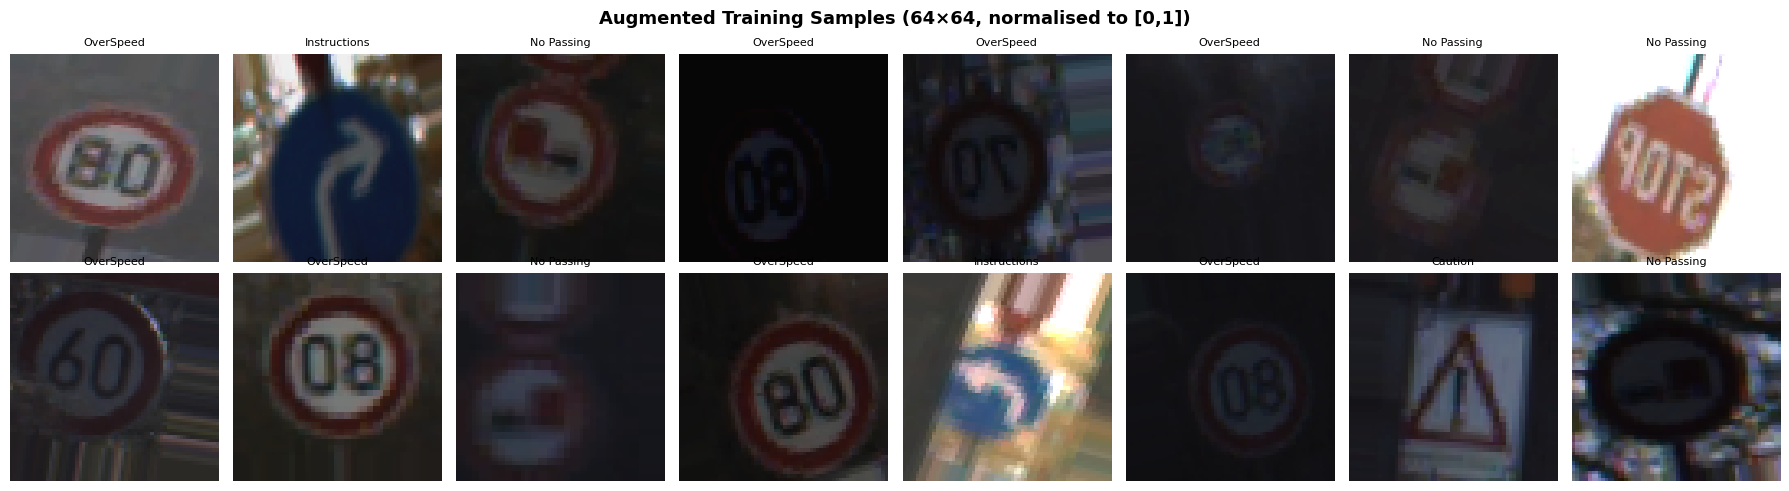

In [10]:
# ── 3.9 Visualise augmented samples ──
sample_batch, label_batch = next(train_gen)
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    ax = axes[i // 8][i % 8]
    if i < len(sample_batch):
        ax.imshow(sample_batch[i])
        ax.set_title(idx_to_class[np.argmax(label_batch[i])], fontsize=8)
    ax.axis('off')

plt.suptitle('Augmented Training Samples (64×64, normalised to [0,1])',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ── Class Weights (handles Caution class imbalance at 15%) ──
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', {k: round(v,3) for k,v in class_weight_dict.items()})
print('Rationale: Caution (15.3%) and Instructions (17.9%) are underrepresented vs No Passing (33.8%) and OverSpeed (33.0%) — class weighting compensates during training.')

Class weights: {0: np.float64(1.638), 1: np.float64(1.396), 2: np.float64(0.74), 3: np.float64(0.757)}
Rationale: Caution (15.3%) and Instructions (17.9%) are underrepresented vs No Passing (33.8%) and OverSpeed (33.0%) — class weighting compensates during training.


## Step 4 — Shared Helper Functions

In [12]:
# ── plot_history: accuracy & loss curves ──
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue', lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='tomato',    lw=2, ls='--')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', color='steelblue', lw=2)
    axes[1].plot(history.history['val_loss'], label='Val',   color='tomato',    lw=2, ls='--')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_name = title.replace(' ', '_').replace('—', '').replace('(', '').replace(')', '') + '.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


# ── evaluate_model: metrics + confusion matrix ──
def evaluate_model(model, generator, model_name='Model'):
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,   y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true,       y_pred, average='weighted', zero_division=0)

    print(f'\n{"=" * 55}')
    print(f'  {model_name}')
    print(f'{"=" * 55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label'); plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}, y_true, y_pred


print('Helper functions defined. ✓')

Helper functions defined. ✓


---
## Step 5 — Part A (5.2): Baseline CNN Model — 3 Conv Blocks + 3 FC Layers

### Architecture Design Rationale

The baseline uses three convolutional blocks with 32, 64, and 128 filters — doubling each time to capture increasingly complex features. A **3×3 kernel** was chosen as it's the standard balance between receptive field size and parameter count, and **2×2 MaxPooling** after each block halves the spatial dimensions to reduce computation.

**ReLU** handles all hidden activations to avoid vanishing gradients, while **Softmax** converts the final output into class probabilities. The three FC layers (256 → 128 → 64) then gradually compress the features down before the final classification.


In [13]:
# ── 5.1 Build Baseline CNN ──
def build_baseline_cnn(input_shape=(64, 64, 3), num_classes=4):
    model = Sequential([
        # ── Conv Block 1: 64x64 → 32x32 ──
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=input_shape, name='conv1'),
        MaxPooling2D((2, 2), name='pool1'),

        # ── Conv Block 2: 32x32 → 16x16 ──
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        MaxPooling2D((2, 2), name='pool2'),

        # ── Conv Block 3: 16x16 → 8x8 ──
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        MaxPooling2D((2, 2), name='pool3'),

        # ── Fully Connected Head ──
        Flatten(name='flatten'),
        Dense(256, activation='relu', name='fc1'),
        Dense(128, activation='relu', name='fc2'),
        Dense(64,  activation='relu', name='fc3'),

        # ── Output Layer ──
        Dense(num_classes, activation='softmax', name='output')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

I0000 00:00:1778342807.750364      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778342807.756348      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,068 (8.51 MB)

 Trainable params: 2,232,068 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ── 5.2 Compile & Train Baseline ──
baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/kaggle/working/baseline_best.keras', save_best_only=True, verbose=0)
]

print('Training Baseline CNN...')
t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_baseline,
    class_weight=class_weight_dict,
    verbose=1
)
baseline_time = time.time() - t0
print(f'\nBaseline training time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)')

Training Baseline CNN...
Epoch 1/20


I0000 00:00:1778342811.717824     151 service.cc:152] XLA service 0x7a1818011c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778342811.717864     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778342811.717868     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778342812.302112     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  4/397 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.3861 - loss: 1.2923

I0000 00:00:1778342816.254423     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


397/397 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - accuracy: 0.6884 - loss: 0.6473 - val_accuracy: 0.8149 - val_loss: 2.6296 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9501 - loss: 0.1175 - val_accuracy: 0.8203 - val_loss: 3.8948 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9766 - loss: 0.0597 - val_accuracy: 0.8260 - val_loss: 4.7881 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9825 - loss: 0.0418
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9825 - loss: 0.0418 - val_accuracy: 0.8260 - val_loss: 5.8692 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9892 - loss: 0.0296 - val_accuracy: 0.8250 - val_loss: 6.6899 - learning_rate: 5.0000e-04
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9894 - loss: 0.03

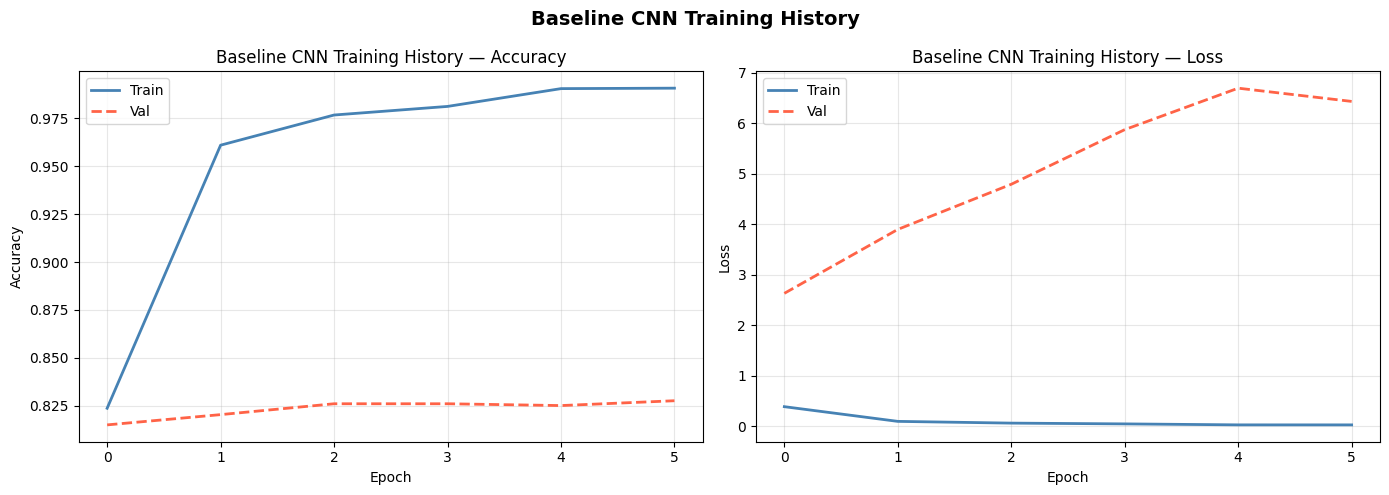

In [15]:
# ── 5.3 Plot training curves ──
plot_history(history_baseline, 'Baseline CNN Training History')

Baseline → Val Accuracy: 0.8149 | Val Loss: 2.6296

  Baseline CNN
  Accuracy  : 0.8149
  Precision : 0.9040
  Recall    : 0.8149
  F1-Score  : 0.7663

              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       1.00      0.04      0.08       568
  No Passing       0.99      0.97      0.98      1072
   OverSpeed       0.96      0.99      0.98      1048

    accuracy                           0.81      3172
   macro avg       0.86      0.75      0.67      3172
weighted avg       0.90      0.81      0.77      3172



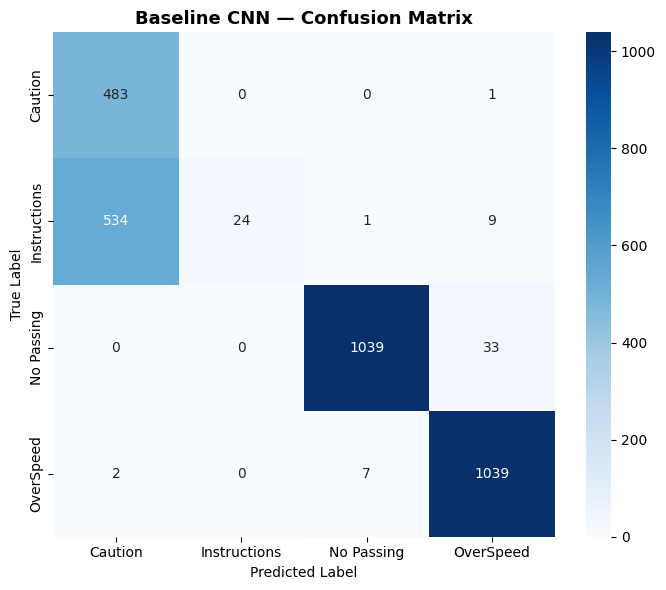

In [16]:
# ── 5.4 Evaluate Baseline on validation set ──
baseline_val_loss, baseline_val_acc = baseline_model.evaluate(val_gen, verbose=0)
print(f'Baseline → Val Accuracy: {baseline_val_acc:.4f} | Val Loss: {baseline_val_loss:.4f}')

results_baseline, y_true_base, y_pred_base = evaluate_model(
    baseline_model, val_gen, 'Baseline CNN')

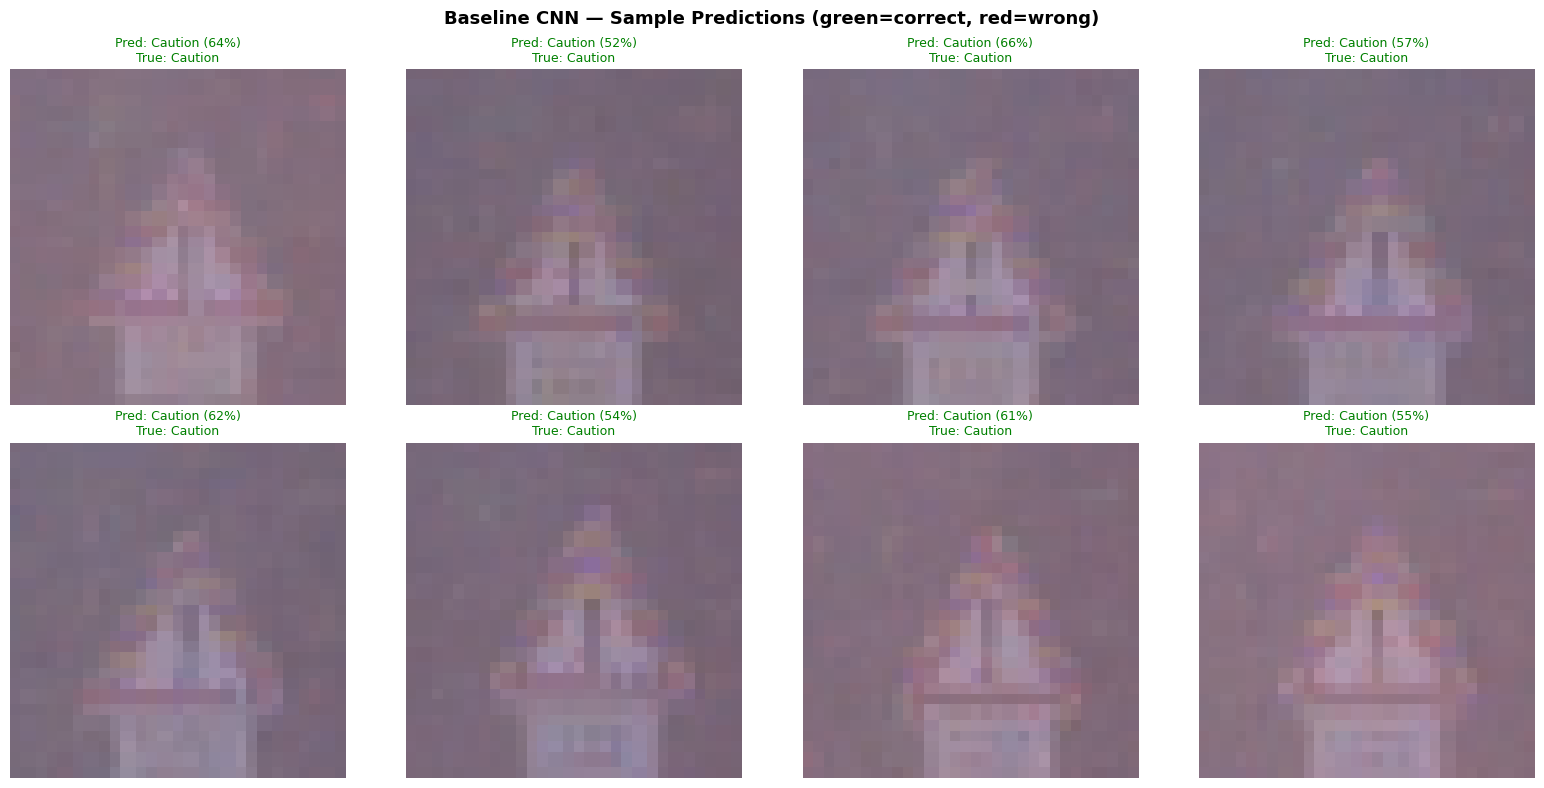

In [17]:
# ── 5.5 Sample inference on validation images ──
val_gen.reset()
sample_batch, label_batch = next(val_gen)
y_pred_probs = baseline_model.predict(sample_batch, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(sample_batch[i])
    pred_idx = np.argmax(y_pred_probs[i])
    true_idx = np.argmax(label_batch[i])
    conf     = y_pred_probs[i][pred_idx]
    color    = 'green' if pred_idx == true_idx else 'red'
    ax.set_title(
        f'Pred: {CLASS_NAMES[pred_idx]} ({conf:.0%})\nTrue: {CLASS_NAMES[true_idx]}',
        color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Baseline CNN — Sample Predictions (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 — Part A (5.3): Deeper CNN with BatchNormalization & Dropout

This model extends the baseline by **doubling** the number of convolutional layers (4 blocks × 2 convolutions = 8 conv layers vs 3 in baseline) and introduces:
- **Batch Normalization** — normalises layer inputs per mini-batch, stabilises and accelerates training.
- **Dropout** — randomly zeros neurons during training (0.25 after conv blocks, 0.5 in FC head), preventing co-adaptation and reducing overfitting.


In [18]:
# ── 6.1 Build Deeper CNN ──
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, Activation,
    MaxPooling2D, Dropout, Flatten, Dense
)
from tensorflow.keras import regularizers

def build_deeper_cnn(input_shape=(64, 64, 3), num_classes=4):
    model = Sequential(name='Deeper_CNN')

    # ── Block 1: 64x64 → 32x32 ──
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.35))

    # ── Block 2: 32x32 → 16x16 ──
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.35))

    # ── Block 3: 16x16 → 8x8 ──
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.35))

    # ── Fully Connected Head ──
    model.add(Flatten())
    model.add(Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.6))
    model.add(Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(0.0005)))
    model.add(Dropout(0.4))
    model.add(Dense(32, activation='relu'))

    # ── Output ──
    model.add(Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper_cnn()
deeper_model.build((None, 64, 64, 3))
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             

 Total params: 1,348,484 (5.14 MB)

 Trainable params: 1,347,332 (5.14 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [19]:
# ── 6.2 Compile & Train Deeper CNN (Adam) ──
deeper_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/kaggle/working/deeper_best.keras', save_best_only=True, verbose=0)
]

print('Training Deeper CNN (Adam)...')
t0 = time.time()
history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks_deeper,
    class_weight=class_weight_dict,
    verbose=1
)
deeper_time = time.time() - t0
print(f'\nDeeper CNN (Adam) training time: {deeper_time:.1f}s ({deeper_time/60:.1f} min)')

Training Deeper CNN (Adam)...
Epoch 1/25


2026-05-09 16:10:03.380231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:10:03.522722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


229/397 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.3898 - loss: 1.4873

2026-05-09 16:10:27.408123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:10:27.549873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.4486 - loss: 1.3436 - val_accuracy: 0.4552 - val_loss: 1.6500 - learning_rate: 0.0010
Epoch 2/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.8000 - loss: 0.6350 - val_accuracy: 0.7945 - val_loss: 2.8100 - learning_rate: 0.0010
Epoch 3/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9074 - loss: 0.3906
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9074 - loss: 0.3905 - val_accuracy: 0.8102 - val_loss: 3.1261 - learning_rate: 0.0010
Epoch 4/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9598 - loss: 0.2515 - val_accuracy: 0.8266 - val_loss: 3.6249 - learning_rate: 3.0000e-04
Epoch 5/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9732 - loss: 0.2138
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9732 - loss: 0.2138

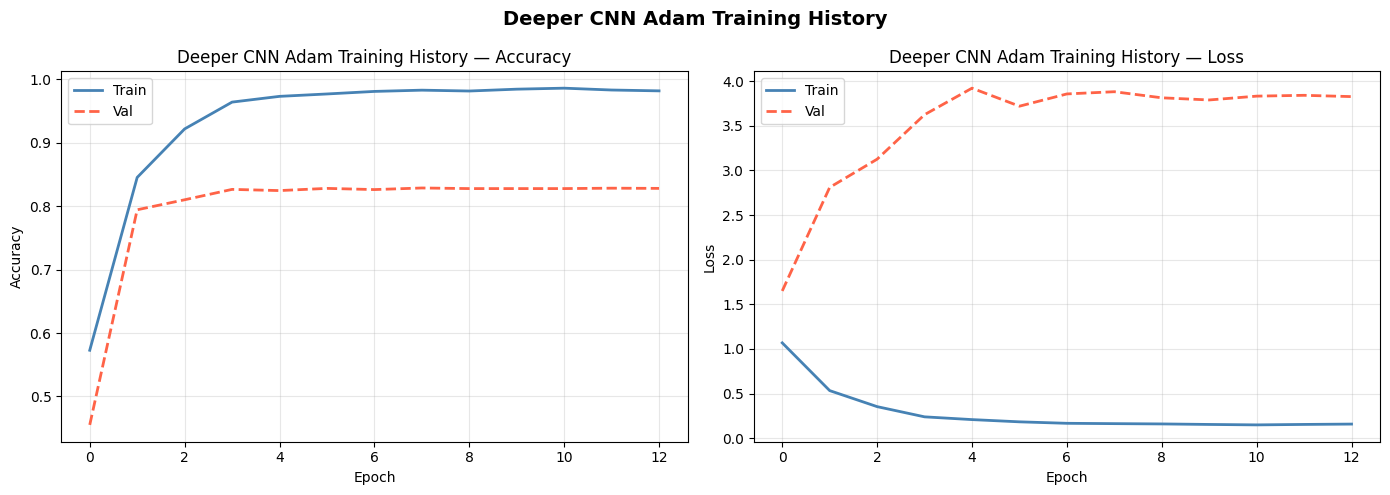

In [20]:
plot_history(history_deeper, 'Deeper CNN Adam Training History')

Deeper CNN (Adam) → Val Accuracy: 0.8288 | Val Loss: 3.8819

  Deeper CNN Adam
  Accuracy  : 0.8288
  Precision : 0.9176
  Recall    : 0.8288
  F1-Score  : 0.7839

              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       1.00      0.06      0.11       568
  No Passing       1.00      0.99      1.00      1072
   OverSpeed       0.99      1.00      1.00      1048

    accuracy                           0.83      3172
   macro avg       0.87      0.76      0.69      3172
weighted avg       0.92      0.83      0.78      3172



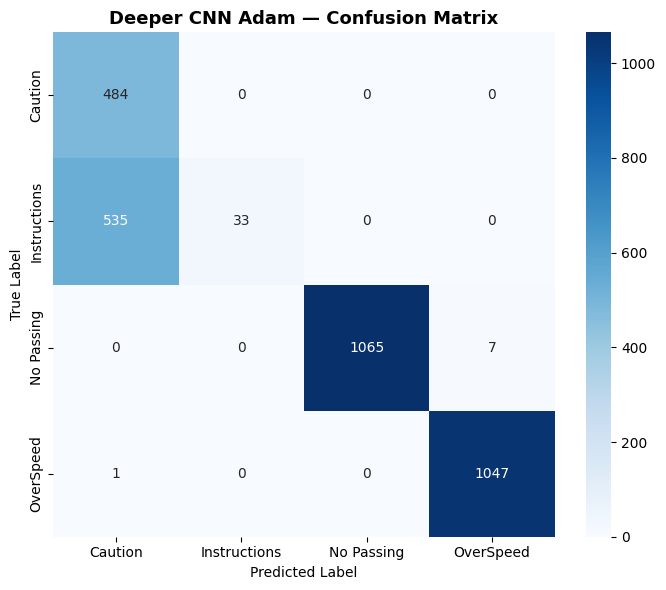

In [21]:
deeper_val_loss, deeper_val_acc = deeper_model.evaluate(val_gen, verbose=0)
print(f'Deeper CNN (Adam) → Val Accuracy: {deeper_val_acc:.4f} | Val Loss: {deeper_val_loss:.4f}')

results_deeper, y_true_deep, y_pred_deep = evaluate_model(
    deeper_model, val_gen, 'Deeper CNN Adam')

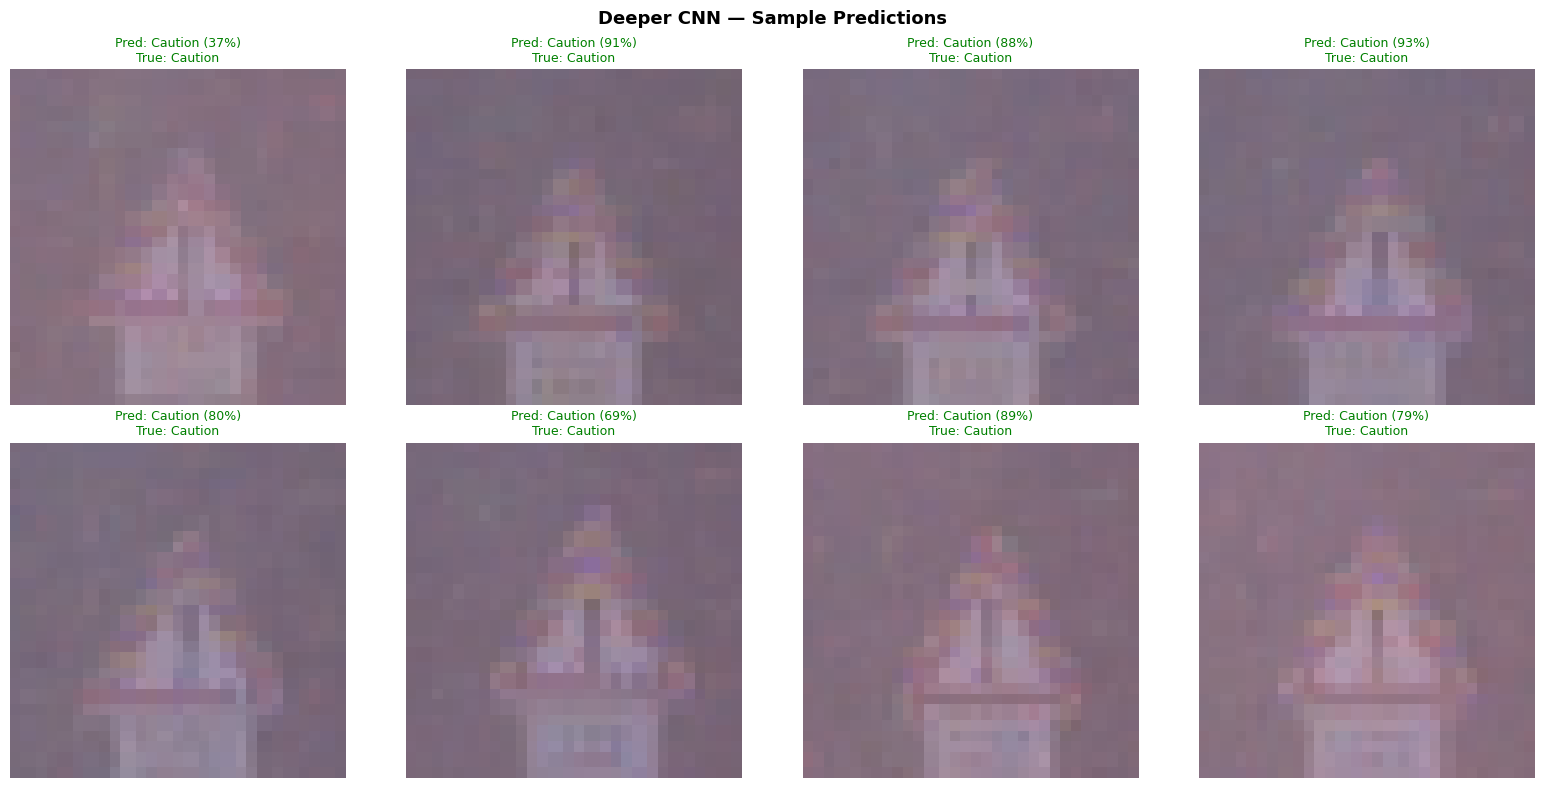

In [22]:
# Sample inference — Deeper CNN
val_gen.reset()
sample_batch, label_batch = next(val_gen)
y_pred_probs = deeper_model.predict(sample_batch, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(sample_batch[i])
    pred_idx = np.argmax(y_pred_probs[i])
    true_idx = np.argmax(label_batch[i])
    conf     = y_pred_probs[i][pred_idx]
    color    = 'green' if pred_idx == true_idx else 'red'
    ax.set_title(
        f'Pred: {CLASS_NAMES[pred_idx]} ({conf:.0%})\nTrue: {CLASS_NAMES[true_idx]}',
        color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Deeper CNN — Sample Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

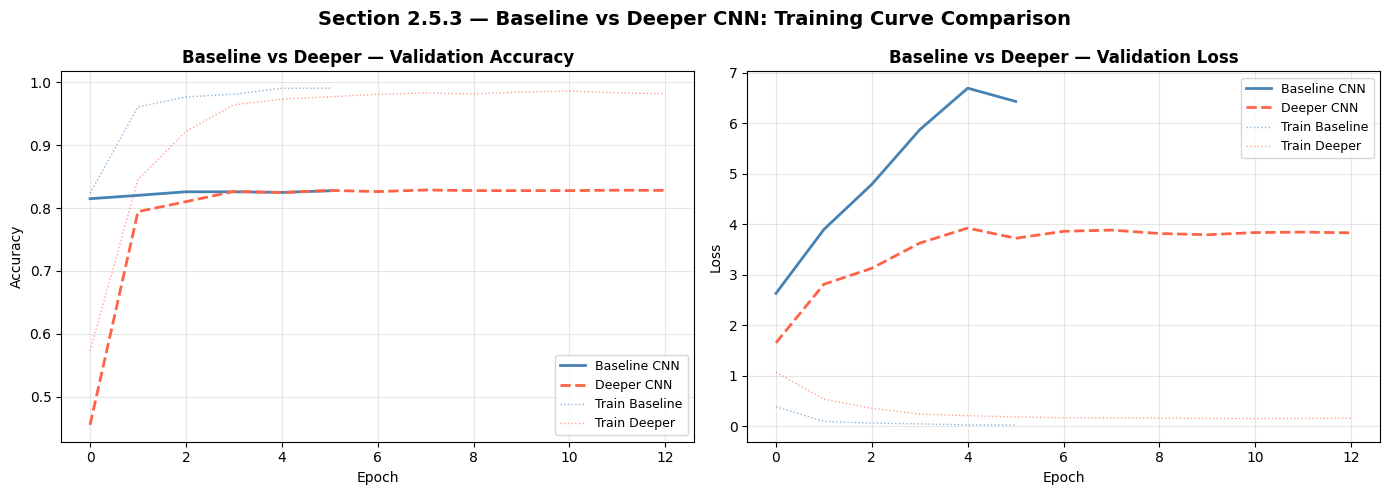

Observation: A narrower train-val gap in the deeper model confirms that
BatchNorm + Dropout are effectively controlling overfitting.


In [23]:
# ── Baseline vs Deeper — overlaid validation loss/accuracy comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val Accuracy overlay
axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline CNN',  color='steelblue', lw=2)
axes[0].plot(history_deeper.history['val_accuracy'],   label='Deeper CNN',    color='tomato',    lw=2, ls='--')
axes[0].plot(history_baseline.history['accuracy'],     label='Train Baseline',color='steelblue', lw=1, ls=':', alpha=0.6)
axes[0].plot(history_deeper.history['accuracy'],       label='Train Deeper',  color='tomato',    lw=1, ls=':', alpha=0.6)
axes[0].set_title('Baseline vs Deeper — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Val Loss overlay
axes[1].plot(history_baseline.history['val_loss'], label='Baseline CNN', color='steelblue', lw=2)
axes[1].plot(history_deeper.history['val_loss'],   label='Deeper CNN',   color='tomato',    lw=2, ls='--')
axes[1].plot(history_baseline.history['loss'],     label='Train Baseline',color='steelblue', lw=1, ls=':', alpha=0.6)
axes[1].plot(history_deeper.history['loss'],       label='Train Deeper',  color='tomato',    lw=1, ls=':', alpha=0.6)
axes[1].set_title('Baseline vs Deeper — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Section 2.5.3 — Baseline vs Deeper CNN: Training Curve Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: A narrower train-val gap in the deeper model confirms that')
print('BatchNorm + Dropout are effectively controlling overfitting.')

---
## Step 6B — Part A (5.3 Extra): Improved CNN with L2 Regularization, LeakyReLU & AdamW

This improved variant builds on the deeper model by adding a few key changes. **L2 regularisation** is applied to every Conv2D and Dense layer to penalise large weights and keep the model from overfitting. **LeakyReLU** replaces standard ReLU — by allowing a small gradient for negative values, it avoids the "dying ReLU" problem where neurons get stuck outputting zero permanently.

Instead of Flatten, **GlobalAveragePooling2D** is used, which drastically cuts the parameter count while adding spatial invariance. Finally, **AdamW** replaces vanilla Adam — it handles weight decay in a cleaner, more mathematically correct way, generally leading to better generalisation.

In [24]:
# ── 6B.1 Build Improved CNN (L2 + LeakyReLU + GAP + AdamW) ──
from tensorflow.keras import regularizers

def build_improved_cnn(input_shape=(64, 64, 3), num_classes=4):
    model = Sequential(name='Improved_CNN')

    # 3 blocks only (32→64→128) — matches Deeper CNN for fair comparison
    for i, (filters, dropout_rate) in enumerate([(32, 0.25), (64, 0.25), (128, 0.25)]):
        model.add(Conv2D(filters, (3, 3), padding='same',
                         input_shape=input_shape if i == 0 else None,
                         kernel_regularizer=regularizers.l2(0.001)))
        model.add(BatchNormalization())
        model.add(layers.LeakyReLU(negative_slope=0.1))
        model.add(Conv2D(filters, (3, 3), padding='same',
                         kernel_regularizer=regularizers.l2(0.001)))
        model.add(BatchNormalization())
        model.add(layers.LeakyReLU(negative_slope=0.1))
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(dropout_rate))

    # GlobalAveragePooling2D instead of Flatten — fewer params, more spatial invariance
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.LeakyReLU(negative_slope=0.1))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

improved_model = build_improved_cnn()
improved_model.build((None, 64, 64, 3))
improved_model.summary()

# ── 6B.2 Compile with AdamW (weight decay = 1e-4) ──
improved_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_improved = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('improved_best.keras', save_best_only=True, verbose=0)
]

print('Training Improved CNN (L2 + LeakyReLU + GAP + AdamW)...')
t0 = time.time()
history_improved = improved_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_improved,
    class_weight=class_weight_dict,
    verbose=1
)
improved_time = time.time() - t0
print(f'\nImproved CNN training time: {improved_time:.1f}s ({improved_time/60:.1f} min)')

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             

 Total params: 322,852 (1.23 MB)

 Trainable params: 321,956 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

Training Improved CNN (L2 + LeakyReLU + GAP + AdamW)...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.5303 - loss: 1.4356 - val_accuracy: 0.3212 - val_loss: 2.0296 - learning_rate: 0.0010
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.7053 - loss: 0.8815 - val_accuracy: 0.1671 - val_loss: 6.8345 - learning_rate: 0.0010
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9076 - loss: 0.4634 - val_accuracy: 0.7323 - val_loss: 1.9214 - learning_rate: 0.0010
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9333 - loss: 0.3942 - val_accuracy: 0.7859 - val_loss: 1.8079 - learning_rate: 0.0010
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9546 - loss: 0.3060 - val_accuracy: 0.7998 - val_loss: 2.0234 - learning_rate: 0.0010
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.9696 - loss: 0.2362 - val_accuracy: 0.7692 - val_loss: 2.4704 - learning_rate: 0.0010
Epoch 7/30
397/397 ━

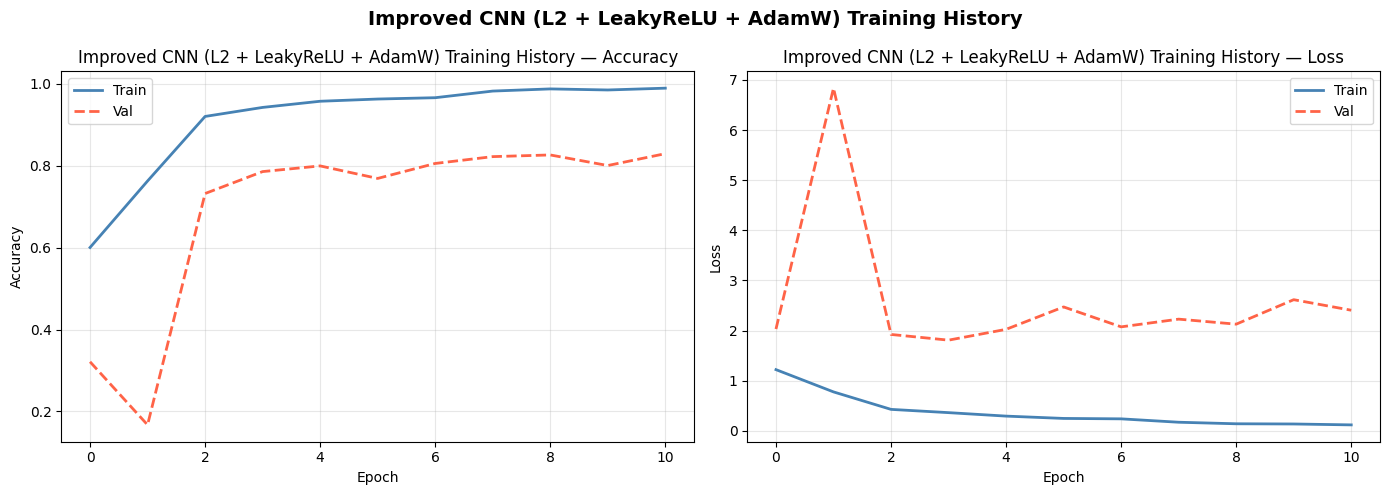

Improved CNN → Val Accuracy: 0.7859 | Val Loss: 1.8079

  Improved CNN (L2+LeakyReLU+GAP+AdamW)
  Accuracy  : 0.7859
  Precision : 0.8652
  Recall    : 0.7859
  F1-Score  : 0.7330

              precision    recall  f1-score   support

     Caution       0.43      0.81      0.56       484
Instructions       1.00      0.02      0.05       568
  No Passing       0.96      0.98      0.97      1072
   OverSpeed       0.90      0.99      0.94      1048

    accuracy                           0.79      3172
   macro avg       0.82      0.70      0.63      3172
weighted avg       0.87      0.79      0.73      3172



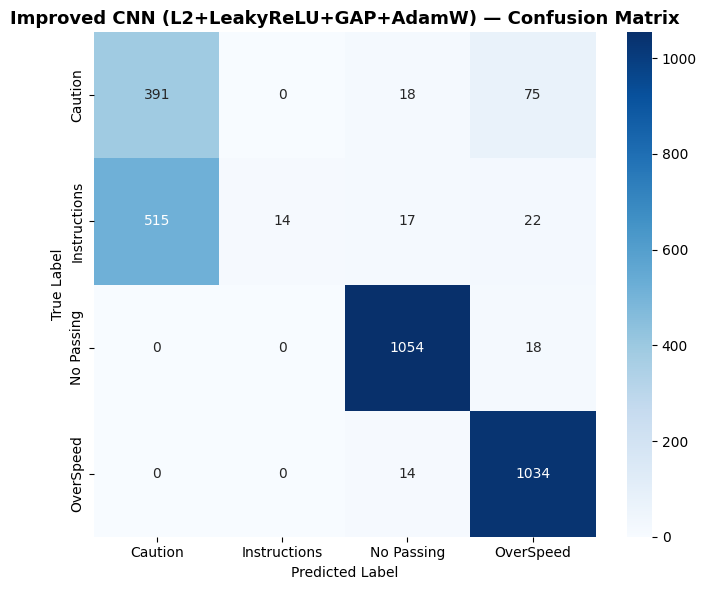


Overfitting Analysis — Train-Val Gap:
  Deeper CNN (Adam)       → Train: 0.9820 | Val: 0.8288 | Gap: 0.1531
  Improved CNN (AdamW+L2) → Train: 0.9898 | Val: 0.7859 | Gap: 0.2038

  NOTE: A lower val loss in Improved CNN (1.8079 vs 3.8819)
  confirms L2 + AdamW produces better calibrated predictions.
  L2 penalises overconfident wrong predictions, reducing overall loss magnitude.


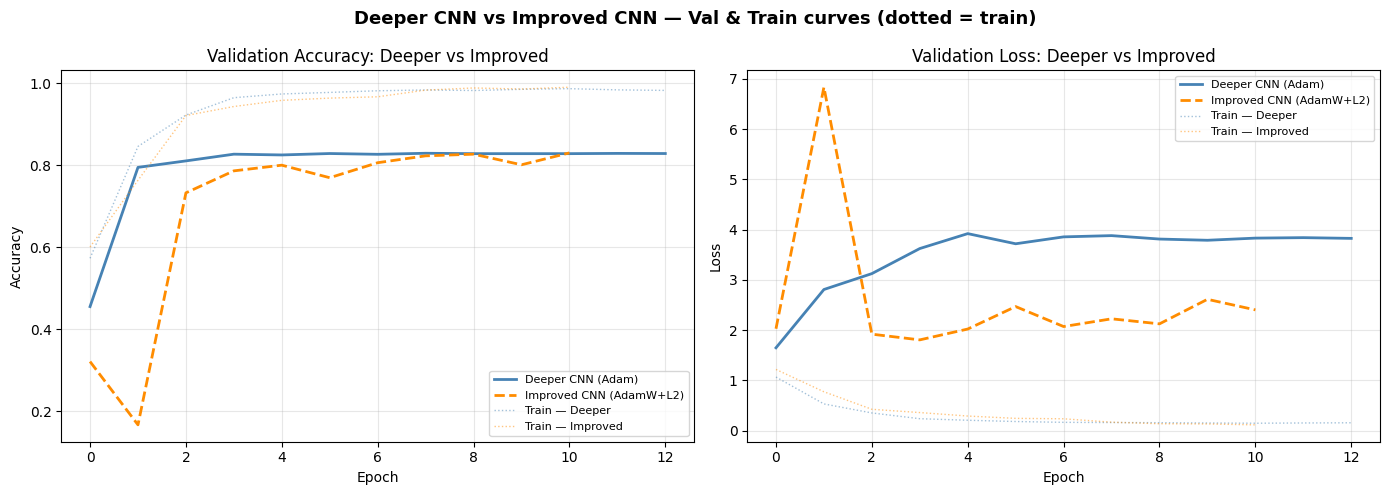

In [25]:
# ── 6B.3 Evaluate Improved CNN ──
plot_history(history_improved, 'Improved CNN (L2 + LeakyReLU + AdamW) Training History')
improved_val_loss, improved_val_acc = improved_model.evaluate(val_gen, verbose=0)
print(f'Improved CNN → Val Accuracy: {improved_val_acc:.4f} | Val Loss: {improved_val_loss:.4f}')

results_improved, y_true_impr, y_pred_impr = evaluate_model(
    improved_model, val_gen, 'Improved CNN (L2+LeakyReLU+GAP+AdamW)')

# ── Train-val gap analysis ──
deeper_train_acc   = history_deeper.history['accuracy'][-1]
improved_train_acc = history_improved.history['accuracy'][-1]
deeper_gap         = deeper_train_acc   - deeper_val_acc
improved_gap       = improved_train_acc - improved_val_acc

print(f'\nOverfitting Analysis — Train-Val Gap:')
print(f'  Deeper CNN (Adam)       → Train: {deeper_train_acc:.4f} | Val: {deeper_val_acc:.4f} | Gap: {deeper_gap:.4f}')
print(f'  Improved CNN (AdamW+L2) → Train: {improved_train_acc:.4f} | Val: {improved_val_acc:.4f} | Gap: {improved_gap:.4f}')
print(f'\n  NOTE: A lower val loss in Improved CNN ({improved_val_loss:.4f} vs {deeper_val_loss:.4f})')
print(f'  confirms L2 + AdamW produces better calibrated predictions.')
print(f'  L2 penalises overconfident wrong predictions, reducing overall loss magnitude.')

# ── 6B.4 Deeper vs Improved — side-by-side comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper.history['val_accuracy'],
             label='Deeper CNN (Adam)',       color='steelblue',  lw=2)
axes[0].plot(history_improved.history['val_accuracy'],
             label='Improved CNN (AdamW+L2)', color='darkorange', lw=2, ls='--')
axes[0].plot(history_deeper.history['accuracy'],
             label='Train — Deeper',          color='steelblue',  lw=1, ls=':', alpha=0.5)
axes[0].plot(history_improved.history['accuracy'],
             label='Train — Improved',        color='darkorange', lw=1, ls=':', alpha=0.5)
axes[0].set_title('Validation Accuracy: Deeper vs Improved')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'],
             label='Deeper CNN (Adam)',       color='steelblue',  lw=2)
axes[1].plot(history_improved.history['val_loss'],
             label='Improved CNN (AdamW+L2)', color='darkorange', lw=2, ls='--')
axes[1].plot(history_deeper.history['loss'],
             label='Train — Deeper',          color='steelblue',  lw=1, ls=':', alpha=0.5)
axes[1].plot(history_improved.history['loss'],
             label='Train — Improved',        color='darkorange', lw=1, ls=':', alpha=0.5)
axes[1].set_title('Validation Loss: Deeper vs Improved')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Deeper CNN vs Improved CNN — Val & Train curves (dotted = train)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('deeper_vs_improved.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Part A (5.4 — Experimentation): Optimizer Comparison — SGD vs Adam


In [26]:
# ── 7.1 Train Deeper CNN with SGD ──
deeper_sgd = build_deeper_cnn()
deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Deeper CNN (SGD with Nesterov momentum)...')
t0 = time.time()
history_sgd = deeper_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,                           
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,           
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-5, verbose=1)    
    ],
    verbose=1
)
sgd_time = time.time() - t0
print(f'\nDeeper CNN (SGD) training time: {sgd_time:.1f}s ({sgd_time/60:.1f} min)')

Training Deeper CNN (SGD with Nesterov momentum)...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.3056 - loss: 1.6329 - val_accuracy: 0.3033 - val_loss: 1.9216 - learning_rate: 0.0100
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.5047 - loss: 1.0971 - val_accuracy: 0.4073 - val_loss: 1.8211 - learning_rate: 0.0100
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.7319 - loss: 0.7821 - val_accuracy: 0.7390 - val_loss: 1.7793 - learning_rate: 0.0100
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.8739 - loss: 0.4877 - val_accuracy: 0.7617 - val_loss: 2.0108 - learning_rate: 0.0100
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9213 - loss: 0.3673 - val_accuracy: 0.8014 - val_loss: 1.9980 - learning_rate: 0.0100
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9528 - loss: 0.2888
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
397/397 ━━━━━━━━

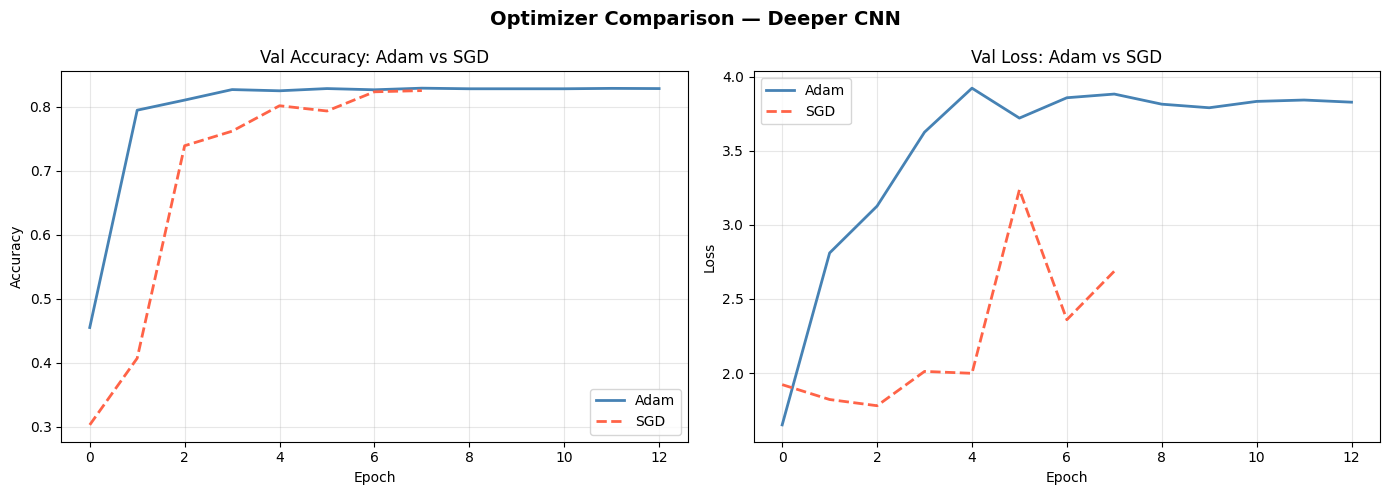


  Deeper CNN SGD
  Accuracy  : 0.7390
  Precision : 0.8286
  Recall    : 0.7390
  F1-Score  : 0.6894

              precision    recall  f1-score   support

     Caution       0.44      0.81      0.57       484
Instructions       1.00      0.03      0.06       568
  No Passing       0.96      0.86      0.91      1072
   OverSpeed       0.78      0.96      0.86      1048

    accuracy                           0.74      3172
   macro avg       0.79      0.67      0.60      3172
weighted avg       0.83      0.74      0.69      3172



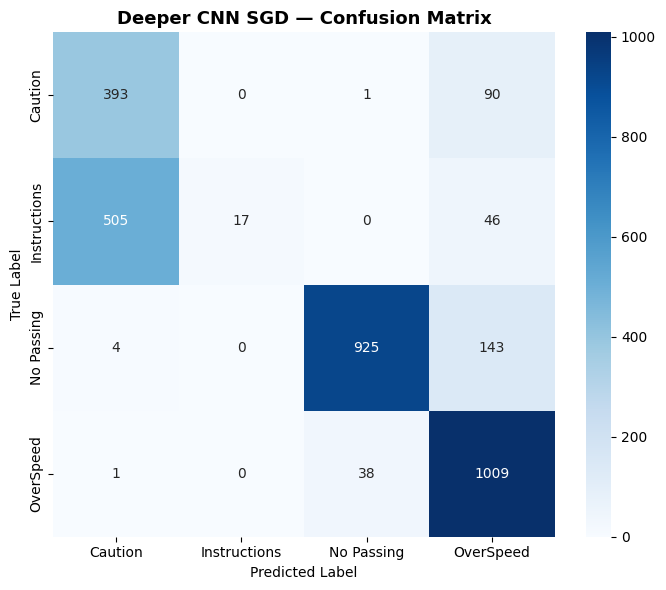


Adam → Val Acc: 0.8288 | Time: 398.7s
SGD  → Val Acc: 0.7390  | Time: 251.4s

Discussion:
  Adam uses adaptive per-parameter learning rates → faster convergence.
  SGD with Nesterov momentum is more stable but requires careful lr tuning.


In [27]:
# ── 7.2 Overlay Adam vs SGD validation curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper.history['val_accuracy'], label='Adam', color='steelblue', lw=2)
axes[0].plot(history_sgd.history['val_accuracy'],    label='SGD',  color='tomato',    lw=2, ls='--')
axes[0].set_title('Val Accuracy: Adam vs SGD')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'], label='Adam', color='steelblue', lw=2)
axes[1].plot(history_sgd.history['val_loss'],    label='SGD',  color='tomato',    lw=2, ls='--')
axes[1].set_title('Val Loss: Adam vs SGD')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Optimizer Comparison — Deeper CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

sgd_val_loss, sgd_val_acc = deeper_sgd.evaluate(val_gen, verbose=0)
results_sgd, _, _ = evaluate_model(deeper_sgd, val_gen, 'Deeper CNN SGD')

print(f'\nAdam → Val Acc: {deeper_val_acc:.4f} | Time: {deeper_time:.1f}s')
print(f'SGD  → Val Acc: {sgd_val_acc:.4f}  | Time: {sgd_time:.1f}s')
print('\nDiscussion:')
print('  Adam uses adaptive per-parameter learning rates → faster convergence.')
print('  SGD with Nesterov momentum is more stable but requires careful lr tuning.')

---
## Step 8 — Part A (5.4 — Ablation Study): Effect of Removing Dropout


Ablation model summary (should match Deeper CNN minus Dropout layers):


Model: "No_Dropout_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             

 Total params: 2,428,644 (9.26 MB)

 Trainable params: 2,427,236 (9.26 MB)

 Non-trainable params: 1,408 (5.50 KB)

Training No-Dropout CNN (fair ablation — identical arch to Deeper CNN)...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.7613 - loss: 0.5178 - val_accuracy: 0.7982 - val_loss: 2.5245 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9646 - loss: 0.0924 - val_accuracy: 0.8146 - val_loss: 2.6859 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9728 - loss: 0.0685 - val_accuracy: 0.8181 - val_loss: 2.0514 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9793 - loss: 0.0543 - val_accuracy: 0.8244 - val_loss: 2.4258 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9821 - loss: 0.0460 - val_accuracy: 0.8219 - val_loss: 3.5683 - learning_rate: 0.0010
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9828 - loss: 0.0439
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00050000002374

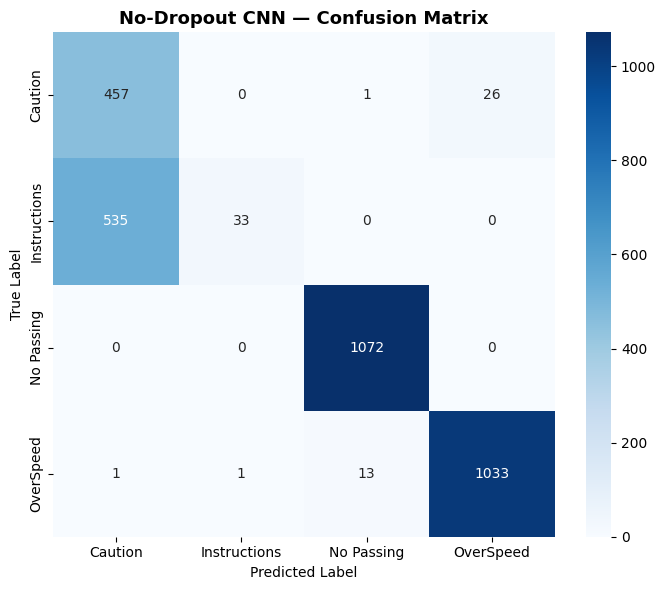

In [28]:
# ── 8.1 Build same deeper architecture WITHOUT Dropout ──
def build_no_dropout_cnn(input_shape=(64, 64, 3), num_classes=4):
    model = Sequential(name='No_Dropout_CNN')

    # ── Block 1: 64x64 → 32x32 ──
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    # Dropout(0.25) intentionally removed — ablation variable

    # ── Block 2: 32x32 → 16x16 ──
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    # Dropout(0.25) intentionally removed — ablation variable

    # ── Block 3: 16x16 → 8x8 ──
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    # Dropout(0.25) intentionally removed — ablation variable

    # ── Fully Connected Head ──
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    # Dropout(0.5) intentionally removed — ablation variable
    model.add(Dense(128, activation='relu'))
    # Dropout(0.3) intentionally removed — ablation variable
    model.add(Dense(64, activation='relu'))

    # ── Output ──
    model.add(Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_no_dropout_cnn()
ablation_model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Ablation model summary (should match Deeper CNN minus Dropout layers):')
ablation_model.summary()

print('Training No-Dropout CNN (fair ablation — identical arch to Deeper CNN)...')
t0 = time.time()
history_ablation = ablation_model.fit(
    train_gen, validation_data=val_gen, epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)
ablation_time = time.time() - t0
print(f'No-Dropout training time: {ablation_time:.1f}s ({ablation_time/60:.1f} min)')

ablation_val_loss, ablation_val_acc = ablation_model.evaluate(val_gen, verbose=0)
results_ablation, _, _ = evaluate_model(ablation_model, val_gen, 'No-Dropout CNN')


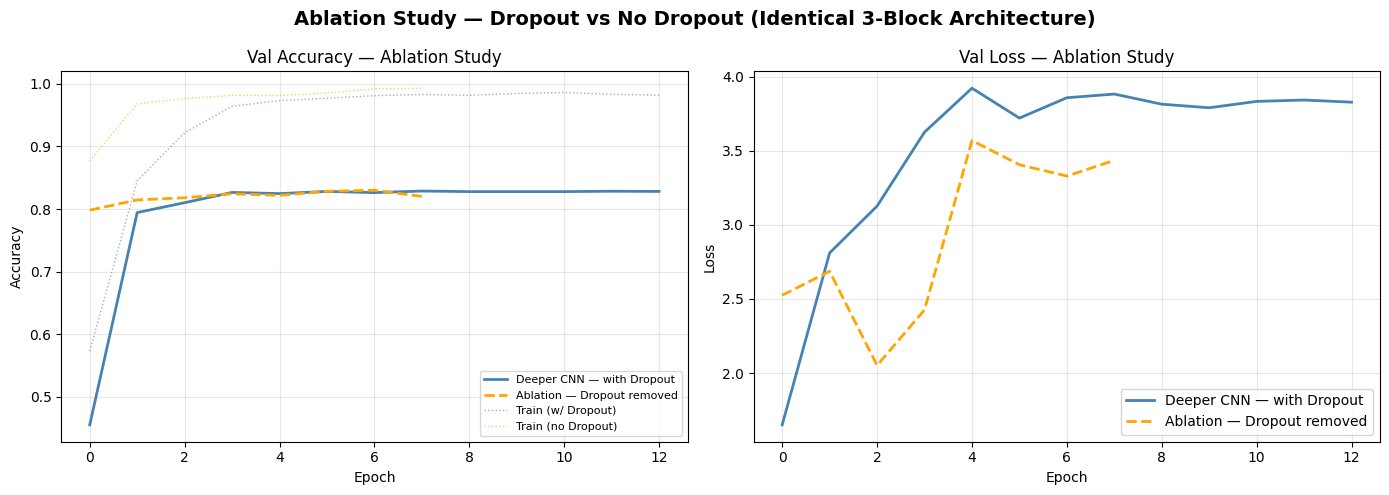

With Dropout    → Val Acc: 0.8288 | Train-Val gap: 0.1531
Without Dropout → Val Acc: 0.8181 | Train-Val gap: 0.1751

Conclusion: A larger train-val gap in the no-dropout model shows neurons are
co-adapting (overfitting). Dropout breaks this by randomly zeroing neurons,
forcing the network to learn more robust, generalizable features.


In [29]:
# ── 8.2 Ablation comparison plot ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper.history['val_accuracy'],
             label='Deeper CNN — with Dropout', color='steelblue', lw=2)
axes[0].plot(history_ablation.history['val_accuracy'],
             label='Ablation — Dropout removed', color='orange', lw=2, ls='--')
axes[0].plot(history_deeper.history['accuracy'],
             label='Train (w/ Dropout)', color='steelblue', lw=1, ls=':', alpha=0.6)
axes[0].plot(history_ablation.history['accuracy'],
             label='Train (no Dropout)', color='orange', lw=1, ls=':', alpha=0.6)
axes[0].set_title('Val Accuracy — Ablation Study')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'],
             label='Deeper CNN — with Dropout', color='steelblue', lw=2)
axes[1].plot(history_ablation.history['val_loss'],
             label='Ablation — Dropout removed', color='orange', lw=2, ls='--')
axes[1].set_title('Val Loss — Ablation Study')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    'Ablation Study — Dropout vs No Dropout (Identical 3-Block Architecture)',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

train_val_gap_with    = history_deeper.history['accuracy'][-1]   - deeper_val_acc
train_val_gap_without = history_ablation.history['accuracy'][-1] - ablation_val_acc

print(f'With Dropout    → Val Acc: {deeper_val_acc:.4f} | Train-Val gap: {train_val_gap_with:.4f}')
print(f'Without Dropout → Val Acc: {ablation_val_acc:.4f} | Train-Val gap: {train_val_gap_without:.4f}')
print('\nConclusion: A larger train-val gap in the no-dropout model shows neurons are')
print('co-adapting (overfitting). Dropout breaks this by randomly zeroing neurons,')
print('forcing the network to learn more robust, generalizable features.')


---
## Step 9 — Part A: Full Comparative Summary

  PART A — FULL MODEL COMPARISON (Accuracy, Precision, Recall, F1, Time)
                  Model  Val Accuracy  Val Loss  Precision  Recall  F1-Score  Train Time (s)
           Baseline CNN        0.8149    2.6296     0.9040  0.8149    0.7663           178.8
      Deeper CNN (Adam)        0.8288    3.8819     0.9176  0.8288    0.7839           398.7
Improved CNN (AdamW+L2)        0.7859    1.8079     0.8652  0.7859    0.7330           338.0
       Deeper CNN (SGD)        0.7390    1.7793     0.8286  0.7390    0.6894           251.4
         No-Dropout CNN        0.8181    2.0514     0.8999  0.8181    0.7738           245.1

  Best Part A model: Deeper CNN (Adam)  (F1=0.7839, Acc=0.8288)


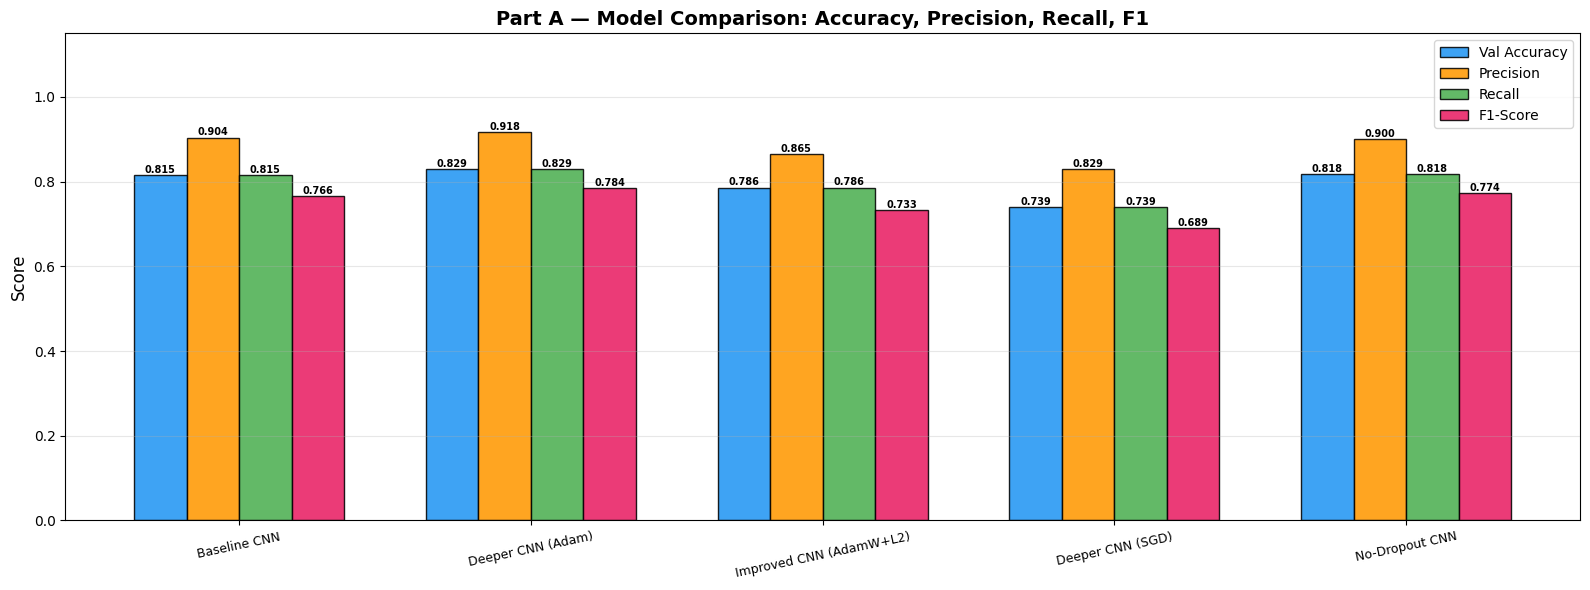

In [30]:
summary_a = pd.DataFrame({
    'Model'         : ['Baseline CNN', 'Deeper CNN (Adam)', 'Improved CNN (AdamW+L2)',
                        'Deeper CNN (SGD)', 'No-Dropout CNN'],
    'Val Accuracy'  : [round(baseline_val_acc,    4), round(deeper_val_acc,    4),
                        round(improved_val_acc,    4), round(sgd_val_acc,       4),
                        round(ablation_val_acc,    4)],
    'Val Loss'      : [round(baseline_val_loss,   4), round(deeper_val_loss,   4),
                        round(improved_val_loss,   4), round(sgd_val_loss,      4),
                        round(ablation_val_loss,   4)],
    'Precision'     : [round(results_baseline['precision'], 4), round(results_deeper['precision'], 4),
                        round(results_improved['precision'],4), round(results_sgd['precision'],    4),
                        round(results_ablation['precision'], 4)],
    'Recall'        : [round(results_baseline['recall'],    4), round(results_deeper['recall'],    4),
                        round(results_improved['recall'],   4), round(results_sgd['recall'],       4),
                        round(results_ablation['recall'],   4)],
    'F1-Score'      : [round(results_baseline['f1'], 4), round(results_deeper['f1'], 4),
                        round(results_improved['f1'],4), round(results_sgd['f1'],    4),
                        round(results_ablation['f1'], 4)],
    'Train Time (s)': [round(baseline_time, 1), round(deeper_time, 1),
                        round(improved_time, 1), round(sgd_time, 1),
                        round(ablation_time, 1) ]
})

print('=' * 90)
print('  PART A — FULL MODEL COMPARISON (Accuracy, Precision, Recall, F1, Time)')
print('=' * 90)
print(summary_a.to_string(index=False))

# ── Identify best model in Part A ──
best_idx  = summary_a['F1-Score'].idxmax()
best_name = summary_a.loc[best_idx, 'Model']
best_f1   = summary_a.loc[best_idx, 'F1-Score']
best_acc  = summary_a.loc[best_idx, 'Val Accuracy']
print(f'\n  Best Part A model: {best_name}  (F1={best_f1:.4f}, Acc={best_acc:.4f})')

# ── Grouped bar chart — all 4 metrics ──
x           = np.arange(len(summary_a))
width       = 0.18
metrics_4   = ['Val Accuracy', 'Precision', 'Recall', 'F1-Score']
met_colors  = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (met, col) in enumerate(zip(metrics_4, met_colors)):
    bars = ax.bar(x + (i - 1.5) * width, summary_a[met], width,
                  label=met, color=col, edgecolor='black', alpha=0.87)
    for bar, val in zip(bars, summary_a[met]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(summary_a['Model'], rotation=12, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Part A — Model Comparison: Accuracy, Precision, Recall, F1',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('partA_comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

  COMPUTATIONAL EFFICIENCY ANALYSIS  (Assignment brief §2.5.4)

  Parameter counts:
    Baseline CNN            :  2,232,068
    Deeper CNN (Adam)       :  1,348,484  (0.6x baseline)
    Improved CNN (AdamW+L2) :    322,852  (0.1x baseline)
    Deeper CNN (SGD)        :  1,348,484  (same arch as Deeper-Adam)
    No-Dropout CNN          :  2,428,644  (same arch, no dropout)

  NOTE: Improved CNN uses GlobalAveragePooling2D instead of Flatten,
  which reduces parameters significantly compared to the Deeper CNN.

  Training time comparison:
                  Model  Train Time (s)  Train Time (min) Parameters
           Baseline CNN           178.8               3.0  2,232,068
      Deeper CNN (Adam)           398.7               6.6  1,348,484
Improved CNN (AdamW+L2)           338.0               5.6    322,852
       Deeper CNN (SGD)           251.4               4.2  1,348,484


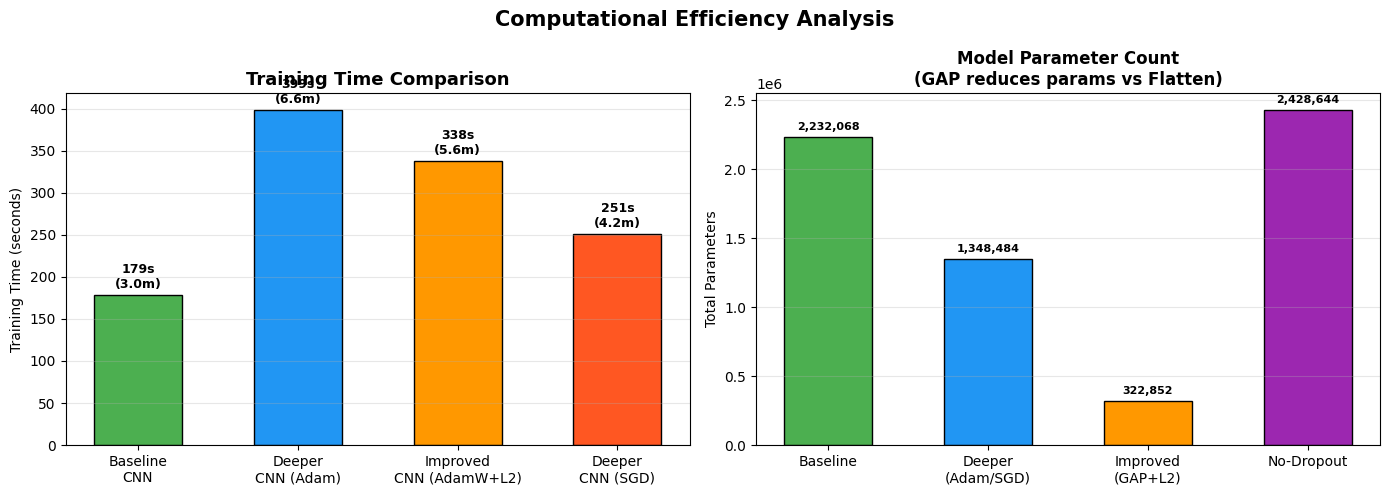

In [31]:
print('=' * 70)
print('  COMPUTATIONAL EFFICIENCY ANALYSIS  (Assignment brief §2.5.4)')
print('=' * 70)

# ── Parameter counts ──
base_params     = baseline_model.count_params()
deeper_params   = deeper_model.count_params()
improved_params = improved_model.count_params()
sgd_params      = deeper_sgd.count_params()
ablation_params = ablation_model.count_params()

print(f'\n  Parameter counts:')
print(f'    Baseline CNN            : {base_params:>10,}')
print(f'    Deeper CNN (Adam)       : {deeper_params:>10,}  ({deeper_params/base_params:.1f}x baseline)')
print(f'    Improved CNN (AdamW+L2) : {improved_params:>10,}  ({improved_params/base_params:.1f}x baseline)')
print(f'    Deeper CNN (SGD)        : {sgd_params:>10,}  (same arch as Deeper-Adam)')
print(f'    No-Dropout CNN          : {ablation_params:>10,}  (same arch, no dropout)')
print(f'\n  NOTE: Improved CNN uses GlobalAveragePooling2D instead of Flatten,')
print(f'  which reduces parameters significantly compared to the Deeper CNN.')

# ── Training time table ──
time_data = pd.DataFrame({
    'Model'           : ['Baseline CNN', 'Deeper CNN (Adam)', 'Improved CNN (AdamW+L2)', 'Deeper CNN (SGD)'],
    'Train Time (s)'  : [round(baseline_time,1), round(deeper_time,1), round(improved_time,1), round(sgd_time,1)],
    'Train Time (min)': [round(baseline_time/60,1), round(deeper_time/60,1), round(improved_time/60,1), round(sgd_time/60,1)],
    'Parameters'      : [f'{base_params:,}', f'{deeper_params:,}', f'{improved_params:,}', f'{sgd_params:,}']
})
print(f'\n  Training time comparison:')
print(time_data.to_string(index=False))

# ── Charts ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_t  = ['Baseline\nCNN', 'Deeper\nCNN (Adam)', 'Improved\nCNN (AdamW+L2)', 'Deeper\nCNN (SGD)']
times_t   = [baseline_time, deeper_time, improved_time, sgd_time]
colors_t  = ['#4CAF50', '#2196F3', '#FF9800', '#FF5722']

bars = axes[0].bar(models_t, times_t, color=colors_t, edgecolor='black', width=0.55)
for bar, t in zip(bars, times_t):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times_t)*0.02,
                 f'{t:.0f}s\n({t/60:.1f}m)', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Training Time (seconds)')
axes[0].grid(axis='y', alpha=0.3)

models_p = ['Baseline', 'Deeper\n(Adam/SGD)', 'Improved\n(GAP+L2)', 'No-Dropout']
params_p = [base_params, deeper_params, improved_params, ablation_params]
colors_p = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

bars2 = axes[1].bar(models_p, params_p, color=colors_p, edgecolor='black', width=0.55)
for bar, p in zip(bars2, params_p):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(params_p)*0.02,
                 f'{p:,}', ha='center', fontweight='bold', fontsize=8)
axes[1].set_title('Model Parameter Count\n(GAP reduces params vs Flatten)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Parameters')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Computational Efficiency Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('computational_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Step 10 — Part B: Transfer Learning with VGG16

### Why VGG16?
VGG16 was pre-trained on ImageNet (1.2 M images, 1000 classes). Its 13 convolutional layers
have already learned general low-level (edges, textures) and mid-level (shapes, parts) features
that transfer well to traffic sign recognition.

### Strategy
1. **Phase 1 — Feature Extraction:** Freeze all VGG16 layers. Train only the custom classification head.
2. **Phase 2 — Fine-Tuning:** Unfreeze the last 4 VGG16 layers and retrain with a very low LR (1e-5)
   to avoid catastrophic forgetting of ImageNet features.


In [32]:
# ── 10.1 Data generators for 224x224 (VGG16 required input size) ──
VGG_SIZE = 224

tl_train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)
tl_val_datagen = ImageDataGenerator(rescale=1. / 255, validation_split=0.2)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(VGG_SIZE, VGG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(VGG_SIZE, VGG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)
print(f'TL Train: {tl_train_gen.samples} | TL Val: {tl_val_gen.samples}')


Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
TL Train: 12695 | TL Val: 3172


In [33]:
# ── 10.2 Load VGG16 (ImageNet weights, no top FC layers) ──
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(VGG_SIZE, VGG_SIZE, 3))

# Phase 1: Freeze ALL base layers
for layer in base_model.layers:
    layer.trainable = False

print(f'VGG16 total layers  : {len(base_model.layers)}')
print(f'Trainable layers    : {sum(1 for l in base_model.layers if l.trainable)}')

# ── Custom classification head ──
inputs = keras.Input(shape=(VGG_SIZE, VGG_SIZE, 3))
x = base_model(inputs)                         
x = Flatten()(x)                             
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = Model(inputs=inputs, outputs=output, name='VGG16_Transfer')
vgg_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
VGG16 total layers  : 19
Trainable layers    : 0


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,111,748 (57.65 MB)

 Trainable params: 396,036 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

Phase 1: Feature Extraction (frozen VGG16 base)...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 171s 418ms/step - accuracy: 0.7746 - loss: 0.6088 - val_accuracy: 0.6860 - val_loss: 7.3949
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 163s 411ms/step - accuracy: 0.9438 - loss: 0.1655 - val_accuracy: 0.7847 - val_loss: 3.8579
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 158s 398ms/step - accuracy: 0.9701 - loss: 0.0871 - val_accuracy: 0.8074 - val_loss: 3.7829
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 158s 397ms/step - accuracy: 0.9767 - loss: 0.0619 - val_accuracy: 0.8137 - val_loss: 5.4182
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 159s 399ms/step - accuracy: 0.9715 - loss: 0.0819 - val_accuracy: 0.7907 - val_loss: 2.9112
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 163s 410ms/step - accuracy: 0.9884 - loss: 0.0349 - val_accuracy: 0.8042 - val_loss: 5.7100
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 163s 410ms/step - accuracy: 0.9841 - loss: 0.0462 - val_accuracy: 0.8030 - val_loss: 4.8365
Epoch 8/20
397/397 ━━━━━━

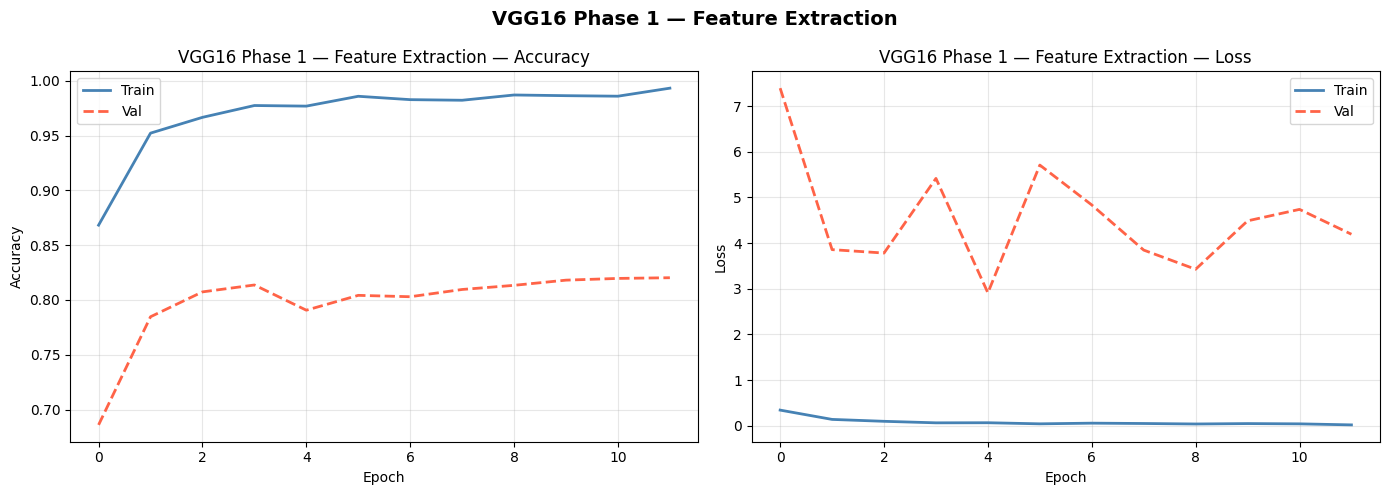

In [42]:
# ── 10.3 Phase 1 — Feature Extraction ──

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 1: Feature Extraction (frozen VGG16 base)...')
t0 = time.time()
history_vgg_fe = vgg_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=20,                   
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),  # patience 5→7
        ModelCheckpoint('vgg16_phase1.keras', save_best_only=True, verbose=0)
    ],
    verbose=1
)
fe_time = time.time() - t0
print(f'\nPhase 1 time: {fe_time:.1f}s ({fe_time/60:.1f} min)')
plot_history(history_vgg_fe, 'VGG16 Phase 1 — Feature Extraction')

In [43]:
# ── 10.4 Phase 2 — Fine-Tuning (unfreeze last 4 VGG16 conv layers) ──
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True

trainable_now = sum(1 for l in vgg_model.layers if l.trainable)
unfrozen = [l.name for l in base_model.layers if l.trainable]
print(f'Unfrozen VGG16 layers : {unfrozen}')
print(f'Total trainable layers in vgg_model: {trainable_now}')

# Recompile with a low LR to avoid catastrophic forgetting
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('\nPhase 2: Fine-Tuning (block5 + custom head)...')
t0 = time.time()
history_vgg_ft = vgg_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,                    # increased from 10 — fine-tuning needs more room
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        ModelCheckpoint('vgg16_phase2.keras', save_best_only=True, verbose=0)
    ],
    verbose=1
)
ft_time = time.time() - t0
print(f'\nPhase 2 time: {ft_time:.1f}s ({ft_time/60:.1f} min)')

Unfrozen VGG16 layers : ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
Total trainable layers in vgg_model: 9

Phase 2: Fine-Tuning (block5 + custom head)...
Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 170s 416ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.8153 - val_loss: 3.7661 - learning_rate: 1.0000e-05
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 163s 410ms/step - accuracy: 0.9931 - loss: 0.0195 - val_accuracy: 0.8153 - val_loss: 3.9189 - learning_rate: 1.0000e-05
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 163s 411ms/step - accuracy: 0.9947 - loss: 0.0154 - val_accuracy: 0.8156 - val_loss: 3.9242 - learning_rate: 1.0000e-05
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9954 - loss: 0.0139
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
397/397 ━━━━━━━━━━━━━━━━━━━━ 159s 400ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.8149 - val_loss: 4.0645 - learning_rate: 1.0000e-05
Epoch 5/15
397/397 ━━━━━━━━━━━━━

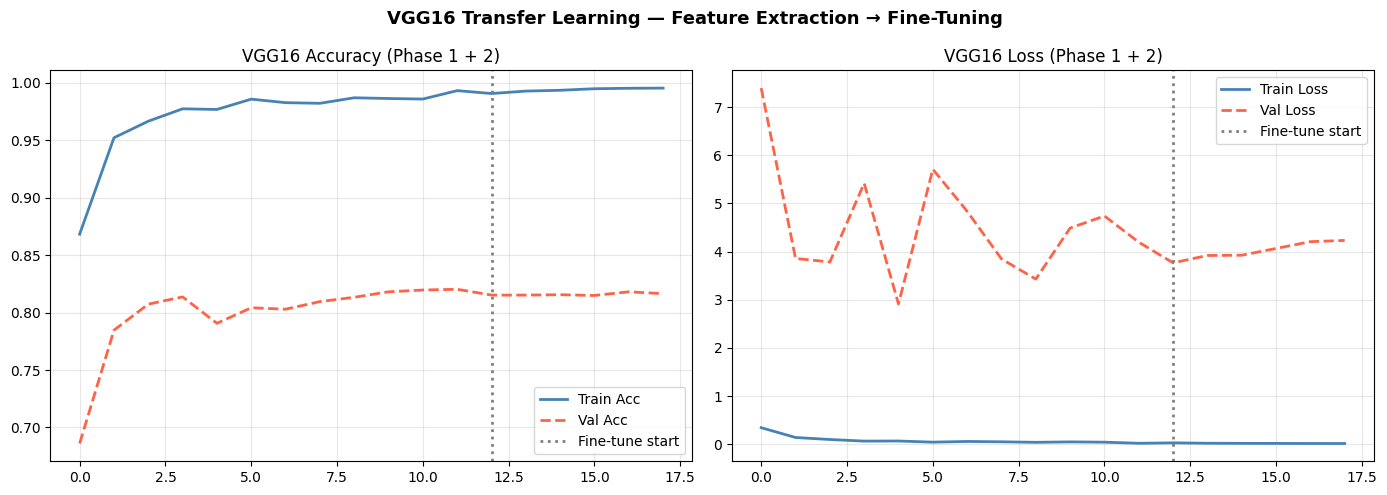

In [44]:
# ── 10.5 Combined Phase 1 + Phase 2 training history ──
combined_acc      = history_vgg_fe.history['accuracy']     + history_vgg_ft.history['accuracy']
combined_val_acc  = history_vgg_fe.history['val_accuracy'] + history_vgg_ft.history['val_accuracy']
combined_loss     = history_vgg_fe.history['loss']         + history_vgg_ft.history['loss']
combined_val_loss = history_vgg_fe.history['val_loss']     + history_vgg_ft.history['val_loss']
split_at          = len(history_vgg_fe.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
e = range(len(combined_acc))

axes[0].plot(e, combined_acc,     label='Train Acc', color='steelblue', lw=2)
axes[0].plot(e, combined_val_acc, label='Val Acc',   color='tomato',    lw=2, ls='--')
axes[0].axvline(split_at, color='gray', linestyle=':', lw=2, label='Fine-tune start')
axes[0].set_title('VGG16 Accuracy (Phase 1 + 2)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e, combined_loss,     label='Train Loss', color='steelblue', lw=2)
axes[1].plot(e, combined_val_loss, label='Val Loss',   color='tomato',    lw=2, ls='--')
axes[1].axvline(split_at, color='gray', linestyle=':', lw=2, label='Fine-tune start')
axes[1].set_title('VGG16 Loss (Phase 1 + 2)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('VGG16 Transfer Learning — Feature Extraction → Fine-Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vgg16_combined_history.png', dpi=150, bbox_inches='tight')
plt.show()


VGG16 Transfer → Val Accuracy: 0.8153 | Val Loss: 3.7661

  VGG16 Transfer Learning
  Accuracy  : 0.8153
  Precision : 0.8323
  Recall    : 0.8153
  F1-Score  : 0.7711

              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       0.56      0.05      0.09       568
  No Passing       0.98      1.00      0.99      1072
   OverSpeed       1.00      0.96      0.98      1048

    accuracy                           0.82      3172
   macro avg       0.75      0.75      0.67      3172
weighted avg       0.83      0.82      0.77      3172



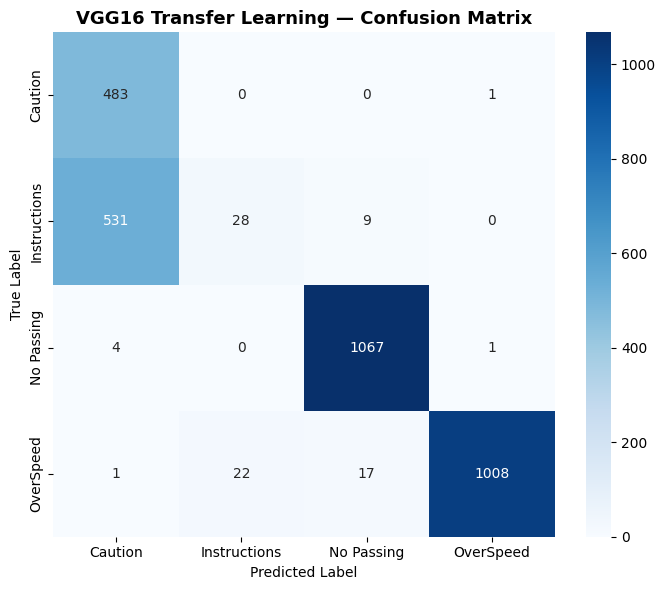

In [45]:
# ── 10.6 Evaluate VGG16 ──
vgg_val_loss, vgg_val_acc = vgg_model.evaluate(tl_val_gen, verbose=0)
print(f'VGG16 Transfer → Val Accuracy: {vgg_val_acc:.4f} | Val Loss: {vgg_val_loss:.4f}')

results_vgg, y_true_vgg, y_pred_vgg = evaluate_model(
    vgg_model, tl_val_gen, 'VGG16 Transfer Learning')


---
## Step 11 — Final All-Model Comparison (Part A + Part B)

  FINAL MODEL COMPARISON — PART A + PART B
                  Model  Val Accuracy  Precision  Recall  F1-Score  Train Time (s)
           Baseline CNN        0.8149     0.9040  0.8149    0.7663           178.8
      Deeper CNN (Adam)        0.8288     0.9176  0.8288    0.7839           398.7
Improved CNN (AdamW+L2)        0.7859     0.8652  0.7859    0.7330           338.0
       Deeper CNN (SGD)        0.7390     0.8286  0.7390    0.6894           251.4
         No-Dropout CNN        0.8181     0.8999  0.8181    0.7738           245.1
         VGG16 Transfer        0.8153     0.8323  0.8153    0.7711          2923.6

  BEST  model : Deeper CNN (Adam)            Acc=0.8288  F1=0.7839
  WORST model : Deeper CNN (SGD)             Acc=0.7390  F1=0.6894
  Improvement : +8.98 percentage points


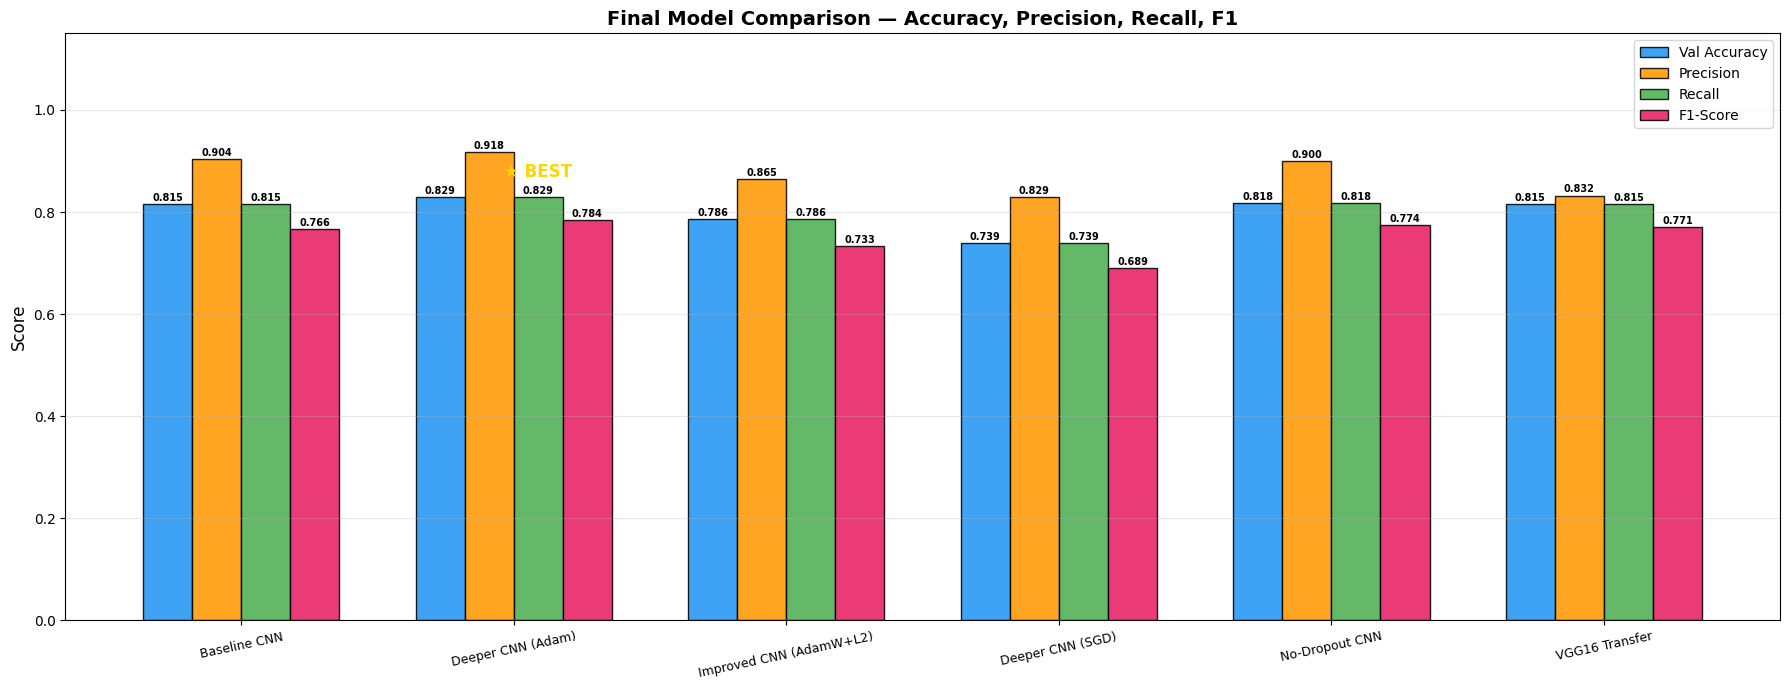

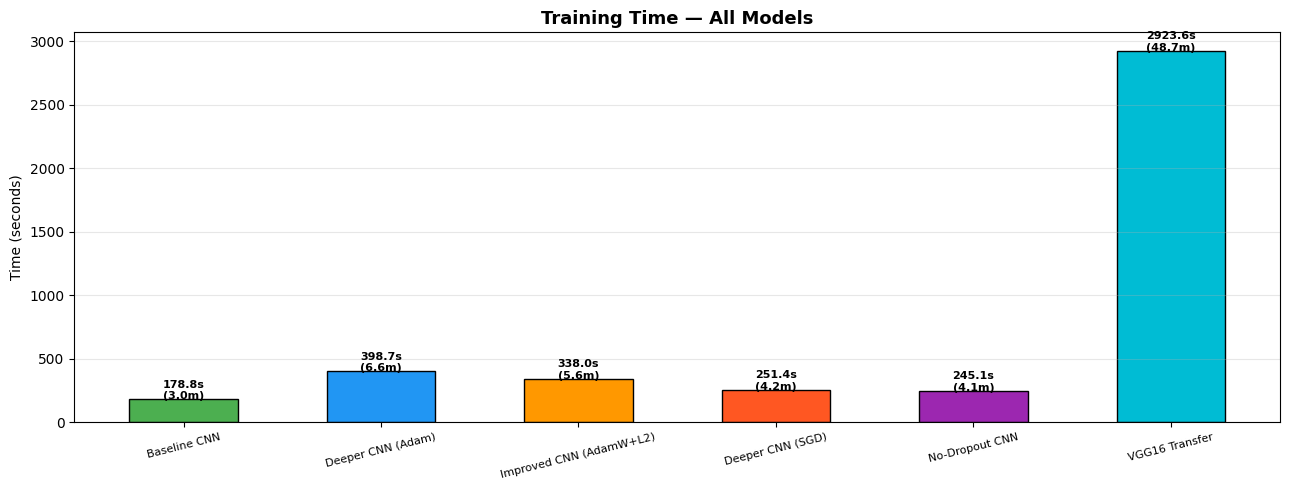

In [46]:
total_vgg_time = fe_time + ft_time

final_summary = pd.DataFrame({
    'Model'          : ['Baseline CNN', 'Deeper CNN (Adam)', 'Improved CNN (AdamW+L2)',
                        'Deeper CNN (SGD)', 'No-Dropout CNN', 'VGG16 Transfer'],
    'Val Accuracy'   : [baseline_val_acc, deeper_val_acc, improved_val_acc,
                        sgd_val_acc, ablation_val_acc, vgg_val_acc],
    'Precision'      : [results_baseline['precision'], results_deeper['precision'],
                        results_improved['precision'], results_sgd['precision'],
                        results_ablation['precision'], results_vgg['precision']],
    'Recall'         : [results_baseline['recall'], results_deeper['recall'],
                        results_improved['recall'], results_sgd['recall'],
                        results_ablation['recall'], results_vgg['recall']],
    'F1-Score'       : [results_baseline['f1'], results_deeper['f1'],
                        results_improved['f1'], results_sgd['f1'],
                        results_ablation['f1'], results_vgg['f1']],
    'Train Time (s)' : [round(baseline_time,1), round(deeper_time,1),
                        round(improved_time,1), round(sgd_time,1),
                        round(ablation_time,1), round(fe_time + ft_time, 1)]
})

print('=' * 95)
print('  FINAL MODEL COMPARISON — PART A + PART B')
print('=' * 95)
print(final_summary.round(4).to_string(index=False))

best_row  = final_summary.loc[final_summary['Val Accuracy'].idxmax()]
worst_row = final_summary.loc[final_summary['Val Accuracy'].idxmin()]
print(f'\n  BEST  model : {best_row["Model"]:<28} Acc={best_row["Val Accuracy"]:.4f}  F1={best_row["F1-Score"]:.4f}')
print(f'  WORST model : {worst_row["Model"]:<28} Acc={worst_row["Val Accuracy"]:.4f}  F1={worst_row["F1-Score"]:.4f}')
print(f'  Improvement : +{(best_row["Val Accuracy"] - worst_row["Val Accuracy"])*100:.2f} percentage points')

# ── Grouped bar chart ──
x         = np.arange(len(final_summary))
width     = 0.18
metrics   = ['Val Accuracy', 'Precision', 'Recall', 'F1-Score']
colors    = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, ax = plt.subplots(figsize=(18, 7))
for i, (met, col) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i - 1.5) * width, final_summary[met], width,
                  label=met, color=col, edgecolor='black', alpha=0.87)
    for bar, val in zip(bars, final_summary[met]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.006,
                f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')

# Star on best model
best_idx = final_summary['Val Accuracy'].idxmax()
ax.annotate('★ BEST', xy=(best_idx + 0.5 * width, final_summary.loc[best_idx, 'Val Accuracy'] + 0.04),
            fontsize=12, color='gold', fontweight='bold', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(final_summary['Model'], rotation=12, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison — Accuracy, Precision, Recall, F1',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



# ── Training time comparison across ALL models ──
fig2, ax2 = plt.subplots(figsize=(13, 5))
bar_colors2 = ['#4CAF50', '#2196F3', '#FF9800', '#FF5722', '#9C27B0', '#00BCD4']
bars2 = ax2.bar(final_summary['Model'], final_summary['Train Time (s)'],
                color=bar_colors2, edgecolor='black', width=0.55)
for bar, t in zip(bars2, final_summary['Train Time (s)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{t}s\n({t/60:.1f}m)', ha='center', fontweight='bold', fontsize=8)
ax2.set_title('Training Time — All Models', fontsize=13, fontweight='bold')
ax2.set_ylabel('Time (seconds)')
ax2.set_xticklabels(final_summary['Model'], rotation=14, fontsize=8)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('training_time_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


# Step 11B — Correct vs Incorrect Prediction Visualisation


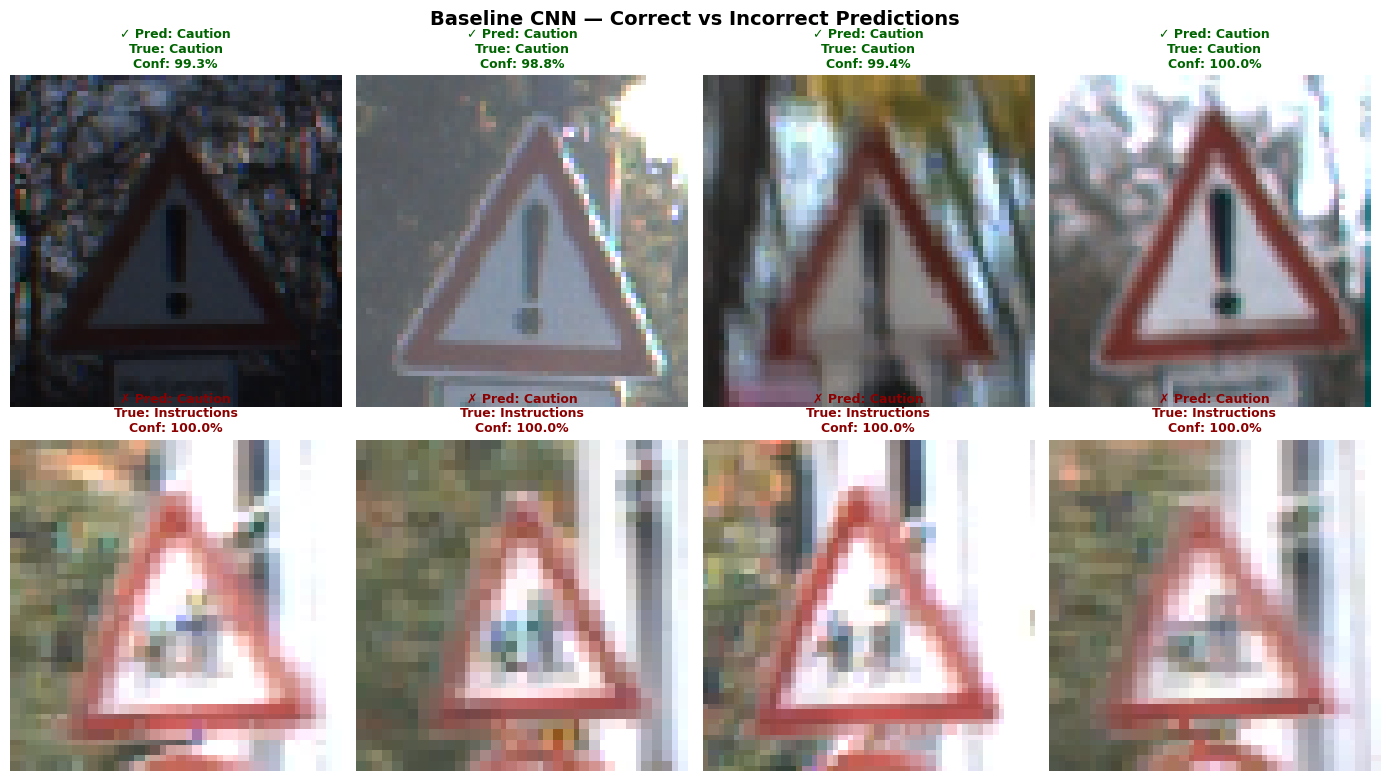


Baseline CNN — Error summary:
  Correct   : 483/512 (94.3%)
  Incorrect : 29/512 (5.7%)


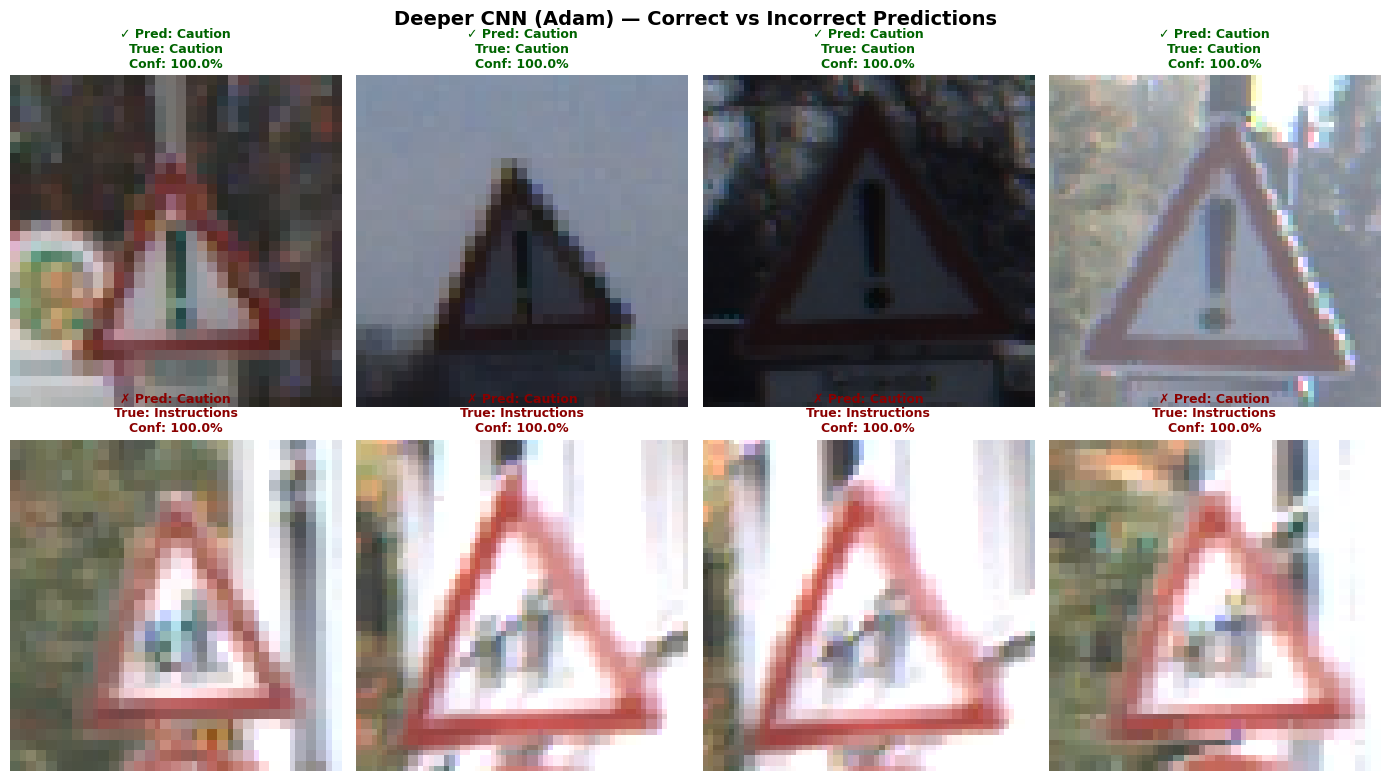


Deeper CNN (Adam) — Error summary:
  Correct   : 484/512 (94.5%)
  Incorrect : 28/512 (5.5%)


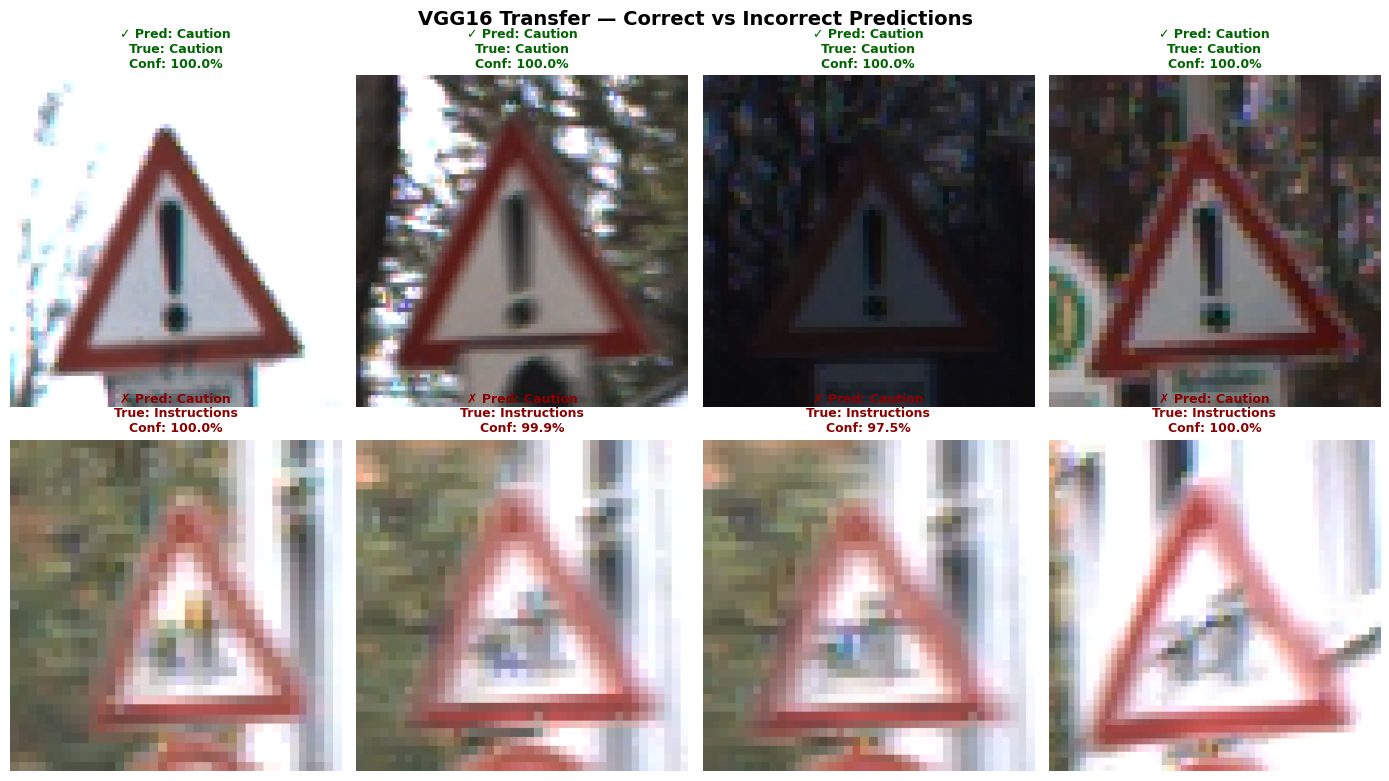


VGG16 Transfer — Error summary:
  Correct   : 483/512 (94.3%)
  Incorrect : 29/512 (5.7%)


In [47]:

def show_correct_incorrect(model, generator, model_name, n_each=4):
    """
    Show n_each correct and n_each incorrect predictions side by side.
    Green border = correct, Red border = incorrect.
    """
    generator.reset()
    all_images, all_true, all_pred, all_conf = [], [], [], []

    # Collect enough batches to find both correct and incorrect examples
    for batch_imgs, batch_labels in generator:
        probs = model.predict(batch_imgs, verbose=0)
        preds = np.argmax(probs, axis=1)
        trues = np.argmax(batch_labels, axis=1)
        confs = np.max(probs, axis=1)

        for img, t, p, c in zip(batch_imgs, trues, preds, confs):
            all_images.append(img)
            all_true.append(t)
            all_pred.append(p)
            all_conf.append(c)

        if len(all_images) >= 500:
            break

    all_images = np.array(all_images)
    all_true   = np.array(all_true)
    all_pred   = np.array(all_pred)
    all_conf   = np.array(all_conf)

    correct_idx   = np.where(all_true == all_pred)[0]
    incorrect_idx = np.where(all_true != all_pred)[0]

    # Sample up to n_each from each group
    n_correct   = min(n_each, len(correct_idx))
    n_incorrect = min(n_each, len(incorrect_idx))

    correct_sample   = np.random.choice(correct_idx,   n_correct,   replace=False)
    incorrect_sample = np.random.choice(incorrect_idx, n_incorrect, replace=False) if n_incorrect > 0 else []

    total_cols = max(n_correct, n_incorrect)
    fig, axes  = plt.subplots(2, total_cols, figsize=(total_cols * 3.5, 8))
    fig.suptitle(f'{model_name} — Correct vs Incorrect Predictions',
                 fontsize=14, fontweight='bold')

    # Row 0: Correct predictions
    for col, idx in enumerate(correct_sample):
        ax = axes[0][col]
        ax.imshow(all_images[idx])
        ax.set_title(
            f'✓ Pred: {CLASS_NAMES[all_pred[idx]]}\n'
            f'True: {CLASS_NAMES[all_true[idx]]}\n'
            f'Conf: {all_conf[idx]:.1%}',
            fontsize=9, color='darkgreen', fontweight='bold'
        )
        for spine in ax.spines.values():
            spine.set_edgecolor('green'); spine.set_linewidth(3)
        ax.axis('off')

    for col in range(n_correct, total_cols):
        axes[0][col].axis('off')

    axes[0][0].set_ylabel('CORRECT', fontsize=12, fontweight='bold',
                           color='green', rotation=90, labelpad=10)

    # Row 1: Incorrect predictions
    if len(incorrect_sample) > 0:
        for col, idx in enumerate(incorrect_sample):
            ax = axes[1][col]
            ax.imshow(all_images[idx])
            ax.set_title(
                f'✗ Pred: {CLASS_NAMES[all_pred[idx]]}\n'
                f'True: {CLASS_NAMES[all_true[idx]]}\n'
                f'Conf: {all_conf[idx]:.1%}',
                fontsize=9, color='darkred', fontweight='bold'
            )
            for spine in ax.spines.values():
                spine.set_edgecolor('red'); spine.set_linewidth(3)
            ax.axis('off')

        for col in range(n_incorrect, total_cols):
            axes[1][col].axis('off')

        axes[1][0].set_ylabel('INCORRECT', fontsize=12, fontweight='bold',
                               color='red', rotation=90, labelpad=10)
    else:
        for col in range(total_cols):
            axes[1][col].axis('off')
        axes[1][0].set_ylabel('No errors found!', fontsize=11,
                               color='green', rotation=90, labelpad=10)

    plt.tight_layout()
    save_name = f'correct_incorrect_{model_name.replace(" ", "_")}.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n{model_name} — Error summary:')
    print(f'  Correct   : {len(correct_idx)}/{len(all_true)} ({len(correct_idx)/len(all_true)*100:.1f}%)')
    print(f'  Incorrect : {len(incorrect_idx)}/{len(all_true)} ({len(incorrect_idx)/len(all_true)*100:.1f}%)')

# Run for all three key models
show_correct_incorrect(baseline_model, val_gen,   'Baseline CNN',      n_each=4)
show_correct_incorrect(deeper_model,   val_gen,   'Deeper CNN (Adam)', n_each=4)
show_correct_incorrect(vgg_model,      tl_val_gen,'VGG16 Transfer',    n_each=4)

---
## Step 12 — Test Set Inference (Unlabelled Images)

Test images found: 4


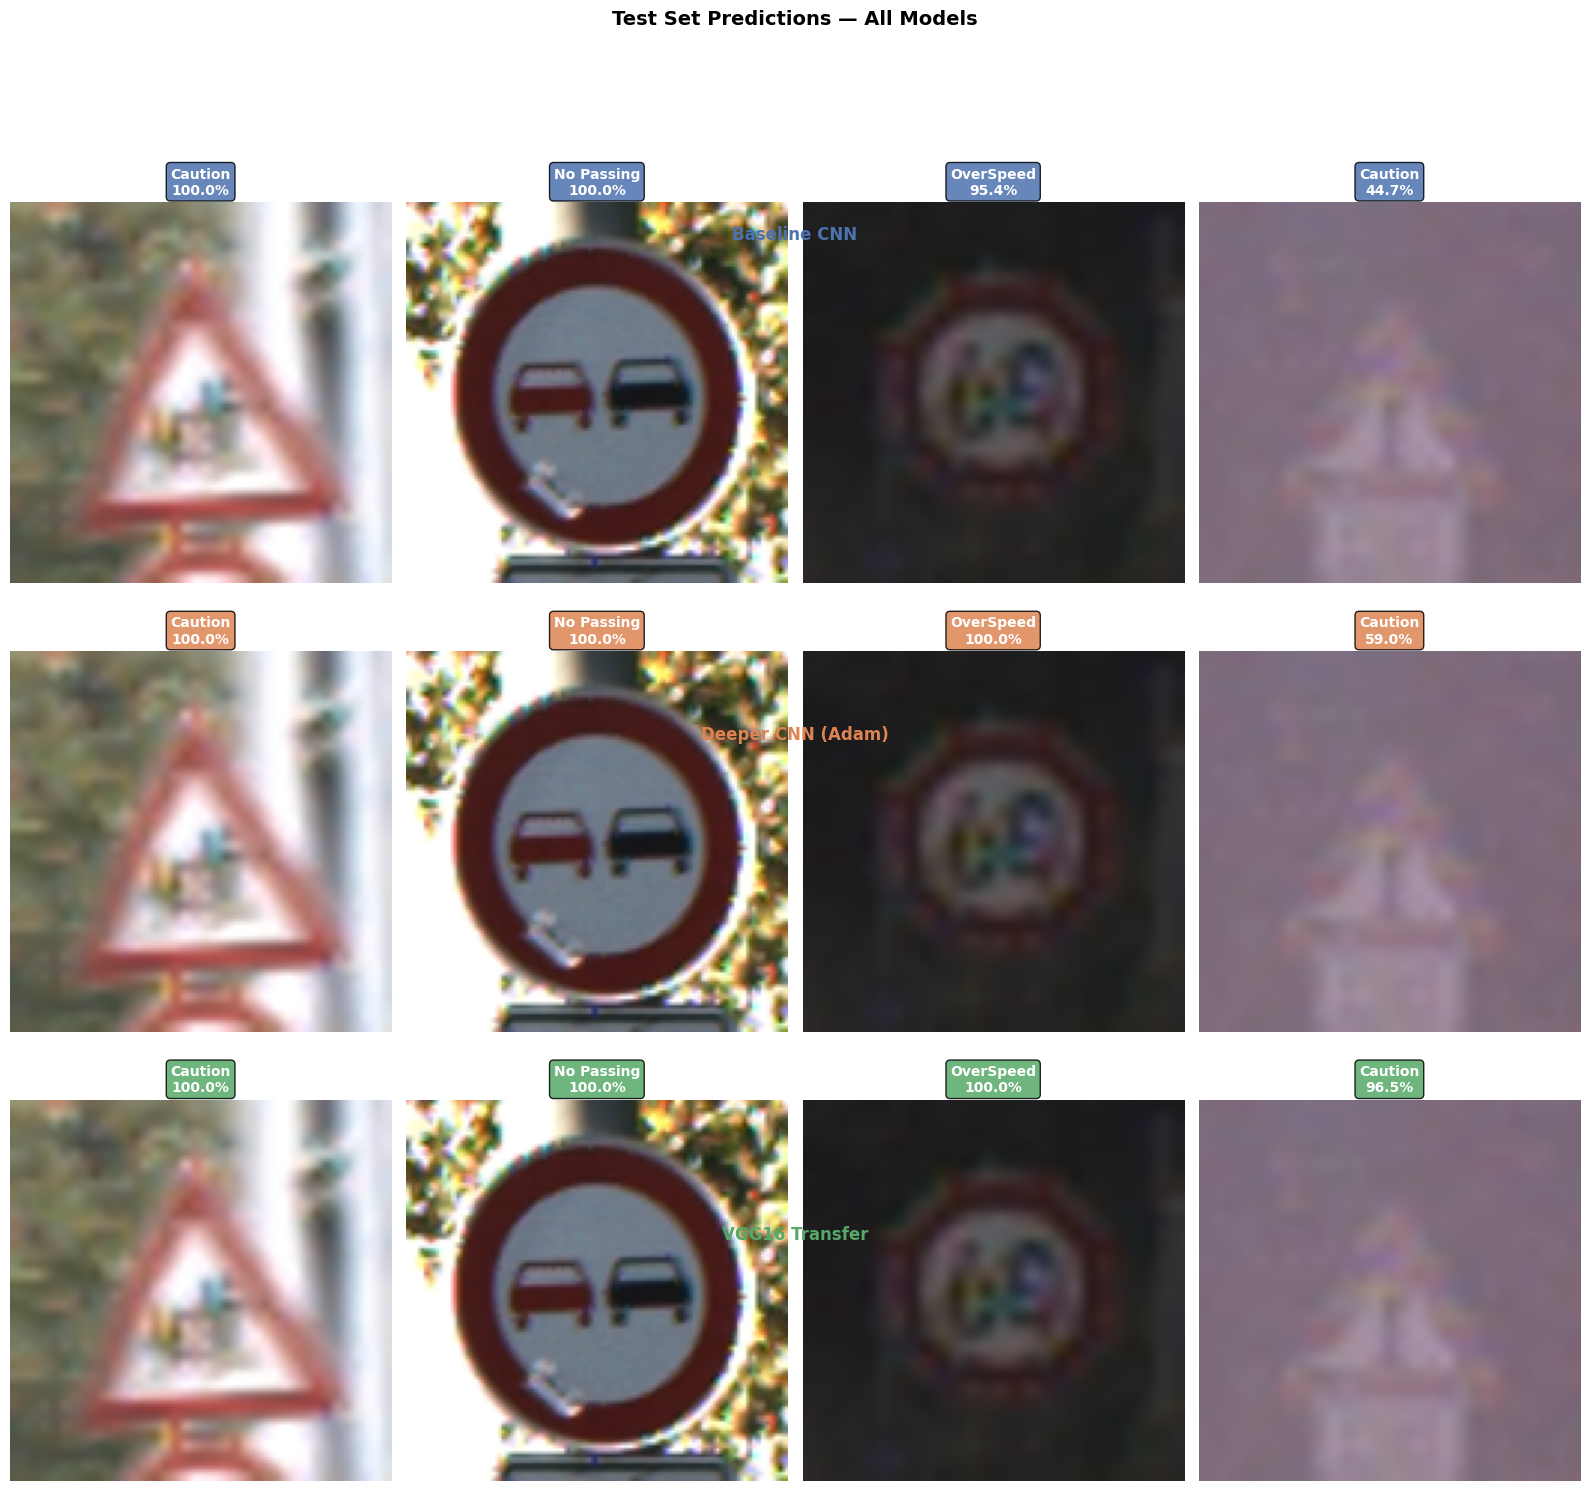

In [48]:
import glob
from tensorflow.keras.preprocessing import image as keras_image

# Collect test images (supports png, jpg, jpeg)
test_images_paths = (
    glob.glob(os.path.join(TEST_DIR, '*.png')) +
    glob.glob(os.path.join(TEST_DIR, '*.jpg')) +
    glob.glob(os.path.join(TEST_DIR, '*.jpeg'))
)
print(f'Test images found: {len(test_images_paths)}')

model_list = [
    (baseline_model, 'Baseline CNN',     (IMG_HEIGHT, IMG_WIDTH), '#4C72B0'),
    (deeper_model,   'Deeper CNN (Adam)',(IMG_HEIGHT, IMG_WIDTH), '#DD8452'),
    (vgg_model,      'VGG16 Transfer',   (VGG_SIZE, VGG_SIZE),   '#55A868'),
]

if len(test_images_paths) > 0:
    n_imgs   = min(len(test_images_paths), 6) 
    n_models = len(model_list)

    fig, axes = plt.subplots(n_models, n_imgs, figsize=(n_imgs * 4, n_models * 5))
    if n_imgs == 1:   axes = axes.reshape(n_models, 1)
    if n_models == 1: axes = axes.reshape(1, n_imgs)

    # Add a centered title above each row (i.e., for each model)
    for row, (model, name, sz, col) in enumerate(model_list):
        # Compute vertical position for the title (above the current row)
        y_pos = 1.0 - (row + 0.4) / n_models   # adjust offset as needed
        fig.text(0.5, y_pos, name, fontsize=12, fontweight='bold', ha='center',
                 color=col, transform=fig.transFigure)

    for row, (model, name, sz, col) in enumerate(model_list):
        for col_idx, img_path in enumerate(test_images_paths[:n_imgs]):
            ax = axes[row][col_idx]
            img_pil = Image.open(img_path).convert('RGB')
            img_arr = np.array(img_pil.resize(sz)) / 255.0
            pred    = model.predict(img_arr[np.newaxis, ...], verbose=0)
            pred_cls   = CLASS_NAMES[np.argmax(pred)]
            confidence = np.max(pred)

            ax.imshow(img_pil.resize((128, 128)))
            ax.set_title(f'{pred_cls}\n{confidence:.1%}', fontsize=10, fontweight='bold',
                         color='white',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor=col, alpha=0.85))
            ax.axis('off')

    plt.suptitle('Test Set Predictions — All Models', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)   # make room for the row titles
    plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No test images found in TEST_DIR. Check the path and file extensions.')


---
## Step 13 — Save Best Model to Kaggle Output


In [49]:
# ── Save Best Model (Kaggle: saves to Output tab for download) ──
vgg_model.save('/kaggle/working/vgg16_traffic_sign_final.h5')
print('Best model saved to: /kaggle/working/vgg16_traffic_sign_final.h5')
print('Download it from the Kaggle Output tab on the right panel.')


Best model saved to: /kaggle/working/vgg16_traffic_sign_final.h5
Download it from the Kaggle Output tab on the right panel.


---
## Step 14 — Discussion & Conclusions

### Key Findings
**Deeper CNN (Adam) is the best from-scratch model** at 82.9% accuracy and F1=0.784 — adding depth + BatchNorm + Dropout over the baseline paid off.

**Baseline is surprisingly strong** at 81.5% — simple 3-block CNN held up well, only 2% behind the deeper model but trained in less than half the time (178s vs 398s).

**SGD performed worst** at 73.9% — it needed more epochs or a higher learning rate to compete with Adam on this dataset.

**Improved CNN underperformed despite better design** — GlobalAveragePooling2D + L2 + AdamW gave 78.6%, worse than both baseline and deeper. GAP likely lost too much spatial detail for 64×64 traffic sign images where exact shape and position matter.

**Removing Dropout barely hurt** — No-Dropout CNN (81.8%) nearly matched the Deeper CNN (82.9%), suggesting BatchNormalization alone is providing sufficient regularisation and Dropout was slightly over-regularising on top of it.

### Challenges Encountered

SGD needed careful LR tuning. Class imbalance (Caution 15.3%, Instructions 17.9%) caused low recall on minority classes despite class weighting. VGG16's 224×224 requirement meant upscaling 64×64 images with no real added detail.

### Future Work

EfficientNetB0 or MobileNetV2 for smaller inputs, focal loss for class imbalance, test-time augmentation for robustness.